In [72]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt


In [73]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
#print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

# Monte Carlo 方法简介

## 1. 方法名称的由来

**Monte Carlo 方法**（蒙特卡罗方法）得名于摩纳哥著名的 Monte Carlo 赌场。  
该名称强调了方法的核心思想：**利用随机性来解决确定性问题**。

与轮盘、骰子等赌博游戏类似，Monte Carlo 方法通过大量随机试验的统计平均，逼近真实结果。

---

## 2. Monte Carlo 方法的历史源起

Monte Carlo 方法的系统性发展始于 **20 世纪 40 年代**，背景是第二次世界大战期间的 **曼哈顿计划**。

当时科学家需要解决如下问题：

- 中子在复杂介质中的输运与扩散
- 高维、强随机性的物理过程
- 无法解析求解或用常规数值方法处理的积分与偏微分方程

---

## 3. Monte Carlo 方法的基本思想

Monte Carlo 方法的核心思想可以概括为：

> 用大量随机样本的统计性质，逼近确定性问题的真实解。

---

### 3.1 定积分的 Monte Carlo 估计

考虑定积分问题：

$$
I = \int_a^b f(x)\,dx.
$$

在区间 $[a,b]$ 上随机生成 $N$ 个样本点 $x_i$，则有近似：

$$
I \approx (b-a)\frac{1}{N}\sum_{i=1}^N f(x_i).
$$

当 $N \to \infty$ 时，该估计在概率意义下收敛到真实积分值。

---

## 4. 收敛性质与误差估计

Monte Carlo 方法的误差满足统计规律：

$$
\epsilon \sim \frac{1}{\sqrt{N}},
$$

其中 $N$ 为样本数量。

其重要特征是：

- 收敛速率与问题维数几乎无关
- 在高维问题中具有显著优势

---

## 5. Monte Carlo 方法的典型应用

### 5.1 高维数值积分

- 统计物理中的配分函数计算
- 量子力学路径积分
- 贝叶斯证据积分

---

### 5.2 随机过程与扩散问题

- 布朗运动模拟
- 随机游走模型
- Fokker–Planck 方程的数值解

---

### 5.3 粒子输运问题

- 中子输运
- 光子传播
- 辐射传输模拟

---

## 6. 从 Monte Carlo 到 Markov Chain Monte Carlo

传统 Monte Carlo 方法依赖独立随机采样。

为解决复杂概率分布的采样问题，发展出了：

**Markov Chain Monte Carlo（MCMC）方法**

其基本思想是：

- 构造一个以目标分布为平稳分布的马尔可夫链
- 通过链的长期演化生成样本

---

### 6.1 典型 MCMC 算法

- Metropolis 算法
- Metropolis–Hastings 算法
- Gibbs 采样
- Hamiltonian Monte Carlo（HMC）

---

## 7. Monte Carlo 方法在现代科学中的地位

Monte Carlo 方法已成为以下领域的核心工具：

- 统计物理
- 贝叶斯统计
- 金融工程
- 机器学习
- 引力波数据分析与参数估计

---

## 8. 小结

Monte Carlo 方法代表了一种重要的计算思想：

> 当解析方法与传统数值方法失效时，  
> 利用随机性与统计规律理解复杂系统。

它并非依赖精巧公式，而是依赖 **概率、统计与计算能力** 的结合。


## 用 Monte Carlo 方法估算抓娃娃机的成功概率与平均价格

### 1. 问题背景与建模动机

抓娃娃机的运行过程包含大量不确定性因素，例如：

- 爪力大小与衰减
- 娃娃的姿态与摩擦
- 抓取路径的随机扰动
- 机器内部设定的“概率机制”

这些因素使得**成功概率难以用解析方法精确计算**。  
因此，可以将抓娃娃机视为一个随机系统，利用 **Monte Carlo 方法** 通过大量重复试验来估计其统计特性。

---

### 2. 抓娃娃过程的随机模型

定义一次抓取的结果为随机变量：

$$
X =
\begin{cases}
1, & \text{抓到娃娃}, \\
0, & \text{未抓到娃娃}.
\end{cases}
$$

假设每次抓取成功的真实概率为 $p$，但该概率在现实中未知。

设每次抓娃娃的成本为：

$$
c = 3 \ \text{元}.
$$

---

### 3. Monte Carlo 估计目标

我们关心以下两个统计量：

#### 3.1 抓到娃娃的概率

通过 Monte Carlo 方法估计成功概率：

$$
\hat{p} = \frac{\text{抓到娃娃的次数}}{\text{总抓取次数}}.
$$

---

#### 3.2 抓到娃娃的平均价格

这是一个条件期望：

$$
\mathbb{E}[\text{价格} \mid \text{抓到娃娃}].
$$

Monte Carlo 估计公式为：

$$
\overline{V} =
\frac{\sum \text{抓到的娃娃价格}}{\text{抓到的次数}}.
$$

---

### 4. Monte Carlo 模拟流程

一次完整的 Monte Carlo 模拟流程如下：

1. 生成随机数 $u \sim \mathrm{Uniform}(0,1)$；
2. 若 $u < p$，则判定抓取成功；
3. 若抓取成功，根据娃娃的价格分布随机抽取一种娃娃；
4. 记录抓取结果与价格；
5. 重复上述步骤 $N$ 次。

当 $N$ 足够大时，统计量将收敛到真实期望值。

---

### 5. Python Monte Carlo 示例代码

In [76]:
import numpy as np

# -----------------------------
# 参数设置
# -----------------------------
N = 1_000        # 模拟次数（越大越准）
p_success = 0.1     # 每次抓到娃娃的真实成功概率（假设）

cost_per_try = 3.0   # 每次抓取费用（元）

# 娃娃类型与价格
prices = 25

# -----------------------------
# Monte Carlo 模拟
# -----------------------------
rng = np.random.default_rng(seed=42)

success_count = 0
total_value = 0.0

for _ in range(N):
    if rng.random() < p_success:
        success_count += 1
        total_value += prices

# -----------------------------
# 统计量
# -----------------------------
p_hat = success_count / N
avg_price = total_value / success_count

expected_cost_per_prize = (N * cost_per_try) / success_count

# -----------------------------
# 输出结果
# -----------------------------
print(f"抓到娃娃的概率 ≈ {p_hat:.4f}")
print(f"抓到的娃娃平均价格 ≈ {avg_price:.2f} 元")
print(f"平均每个娃娃的成本 ≈ {expected_cost_per_prize:.2f} 元")


抓到娃娃的概率 ≈ 0.0950
抓到的娃娃平均价格 ≈ 25.00 元
平均每个娃娃的成本 ≈ 31.58 元


## 用 Monte Carlo 方法计算圆面积并估算圆周率 π

### 1. 基本思想

圆周率 $\pi$ 可以通过**圆的面积公式**得到。

对于半径为 $R=1$ 的圆，其面积为：

$$
A_{\text{circle}} = \pi R^2 = \pi.
$$

如果我们能够用数值方法估算单位圆的面积，就可以反推出 $\pi$。

---

### 2. 几何构造

考虑以下几何区域：

- 正方形：$[0,1]\times[0,1]$
- 单位圆的四分之一：
  $$
  x^2 + y^2 \le 1,\quad x\ge0,\ y\ge0
  $$

四分之一圆的面积为：

$$
A_{\text{quarter}} = \frac{\pi}{4}.
$$

---

### 3. Monte Carlo 方法原理

在正方形 $[0,1]\times[0,1]$ 中：

1. 随机生成大量点 $(x_i,y_i)$，其中
   $$
   x_i,y_i \sim \mathrm{Uniform}(0,1).
   $$
2. 判断点是否落在四分之一圆内：
   $$
   x_i^2 + y_i^2 \le 1.
   $$
3. 设总采样点数为 $N$，其中有 $N_{\text{in}}$ 个点落在圆内。

由于点在正方形内均匀分布，有近似关系：

$$
\frac{N_{\text{in}}}{N} \approx \frac{A_{\text{quarter}}}{1}.
$$

即：

$$
\frac{N_{\text{in}}}{N} \approx \frac{\pi}{4}.
$$

从而得到 $\pi$ 的 Monte Carlo 估计：

$$
\boxed{
\pi \approx 4\,\frac{N_{\text{in}}}{N}
}
$$

---

### 4. 算法流程

Monte Carlo 计算 $\pi$ 的步骤如下：

1. 设定模拟次数 $N$；
2. 在 $[0,1]\times[0,1]$ 内随机生成 $N$ 个点；
3. 统计满足 $x^2 + y^2 \le 1$ 的点数；
4. 根据公式
   $$
   \pi \approx 4\,\frac{N_{\text{in}}}{N}
   $$
   计算近似值。

---

### 5. Python 实现示例


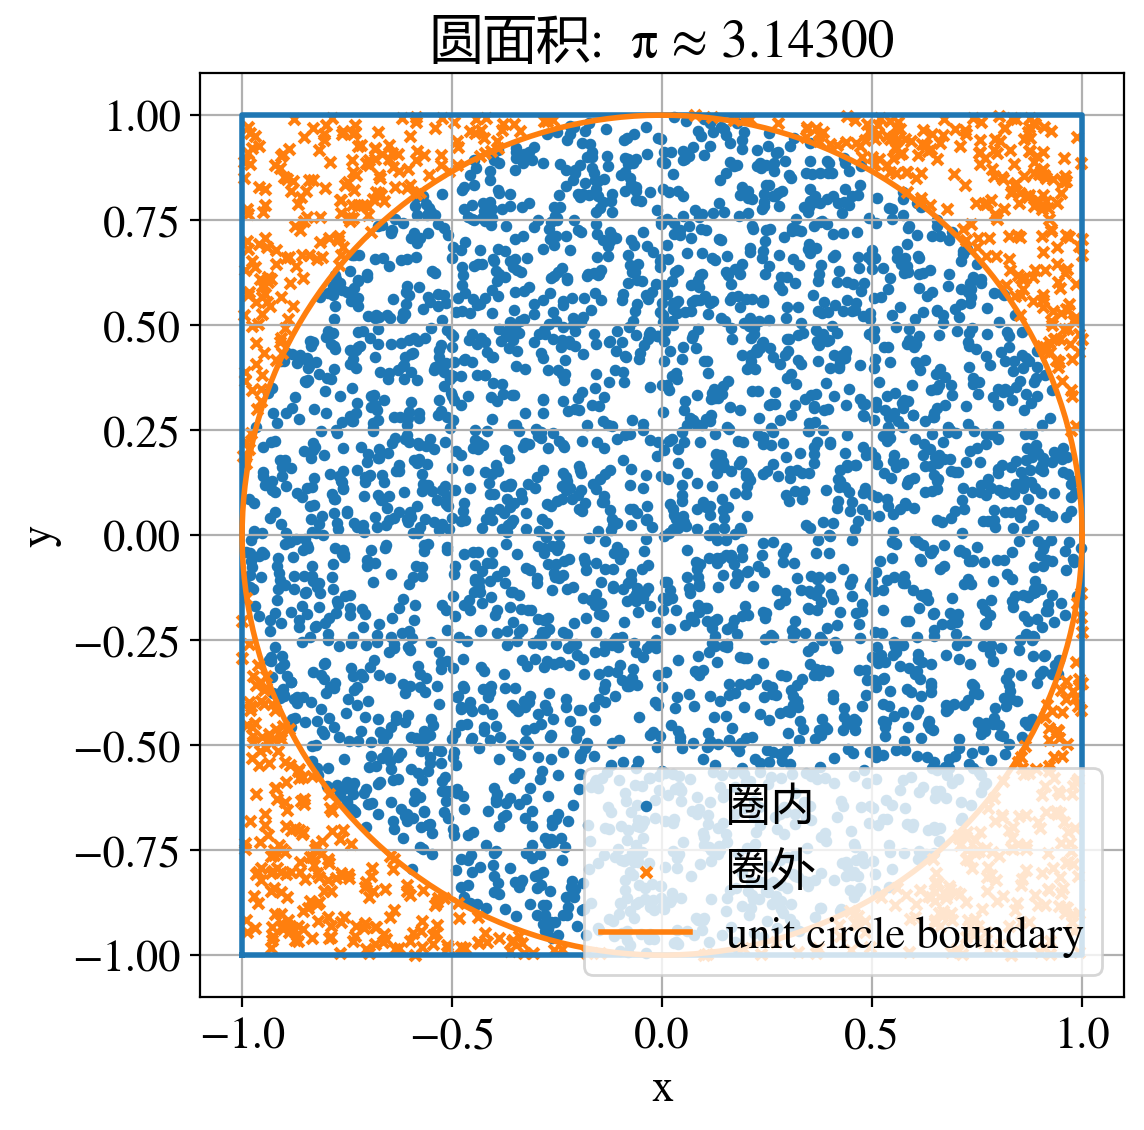

In [78]:
def mc_pi(N=50_000, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 1, N)
    y = rng.uniform(-1, 1, N)
    inside = (x*x + y*y) <= 1.0
    pi_est = 4.0 * np.mean(inside)
    return pi_est, x, y, inside

# “示意图”
pi_est, x, y, inside = mc_pi(N=4000, seed=1)

plt.figure(figsize=(6, 6))
plt.scatter(x[inside],  y[inside],  s=10, marker='o', label="圈内")
plt.scatter(x[~inside], y[~inside], s=15, marker='x', label="圈外")

# 正方形边界
plt.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], linewidth=2)

# 单位圆边界
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="unit circle boundary")

plt.gca().set_aspect("equal", adjustable="box")
plt.title(f"圆面积:  π ≈ {pi_est:.5f}")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


In [79]:
def monte_carlo_pi(N=1_000_000, seed=2025):
    rng = np.random.default_rng(seed)
    
    # 在 [0,1]x[0,1] 中随机采样
    x = rng.uniform(0.0, 1.0, N)
    y = rng.uniform(0.0, 1.0, N)
    
    # 判断是否落在四分之一圆内
    inside = x**2 + y**2 <= 1.0
    N_in = np.sum(inside)
    
    # Monte Carlo 估计 pi
    pi_est = 4.0 * N_in / N
    return pi_est

# 测试不同的采样点数
for N in [1_000, 10_000, 100_000, 1_000_000]:
    pi_est = monte_carlo_pi(N)
    error = abs(pi_est - np.pi)
    print(f"N={N:>7d}, pi≈{pi_est:.6f}, error={error:.6e}")


N=   1000, pi≈3.148000, error=6.407346e-03
N=  10000, pi≈3.138400, error=3.192654e-03
N= 100000, pi≈3.138840, error=2.752654e-03
N=1000000, pi≈3.141604, error=1.134641e-05


## 用 Monte Carlo 方法计算椭球体积

### 1. 问题定义

考虑三维椭球：

$$
\frac{x^2}{a^2}+\frac{y^2}{b^2}+\frac{z^2}{c^2}\le 1,
$$

其中 \(a,b,c>0\) 是三个半轴长度。

该椭球的解析体积公式为：

$$
V_{\text{exact}}=\frac{4}{3}\pi abc.
$$

在这里，我们不依赖解析公式，而是用 **Monte Carlo 方法** 来数值估算椭球体积，从而理解随机采样在几何体积计算中的思想。

---

### 2. Monte Carlo 的核心思想：体积等于比例

#### 2.1 外接盒（Bounding Box）

椭球完全包含在如下长方体中：

$$
x\in[-a,a],\quad
y\in[-b,b],\quad
z\in[-c,c].
$$

该长方体的体积为：

$$
V_{\text{box}} = (2a)(2b)(2c) = 8abc.
$$

---

#### 2.2 随机撒点与比例关系

在外接长方体中 **均匀随机采样** 点：

$$
(x_i,y_i,z_i)\sim
\mathrm{Uniform}([-a,a]\times[-b,b]\times[-c,c]).
$$

定义指示函数：

$$
\mathbf{1}_{\text{in}}(x,y,z)=
\begin{cases}
1,& \dfrac{x^2}{a^2}+\dfrac{y^2}{b^2}+\dfrac{z^2}{c^2}\le 1,\\[6pt]
0,& \text{否则}.
\end{cases}
$$

设：

- 总采样点数为 $N$
- 落在椭球内部的点数为 $N_{\text{in}}$

由于采样是均匀的，有近似关系：

$$
\frac{N_{\text{in}}}{N}
\approx
\frac{V_{\text{ellipsoid}}}{V_{\text{box}}}.
$$

---

### 3. Monte Carlo 体积估计公式

由比例关系直接得到椭球体积的 Monte Carlo 估计公式：

$$
\boxed{
V_{\text{ellipsoid}}
\approx
V_{\text{box}}\frac{N_{\text{in}}}{N} =
8abc\frac{N_{\text{in}}}{N}.
}
$$

这就是 Monte Carlo 方法计算椭球体积的基本公式。

---

### 4. 算法步骤（操作流程）

1. 给定椭球参数 $a,b,c$
2. 在长方体 $[-a,a]\times[-b,b]\times[-c,c] $ 中生成 $N$ 个均匀随机点
3. 对每个点判断是否满足：
   $$
   \frac{x^2}{a^2}+\frac{y^2}{b^2}+\frac{z^2}{c^2}\le 1
   $$
4. 统计落在椭球内部的点数 $N_{\text{in}}$
5. 用公式
   $$
   V \approx 8abc\frac{N_{\text{in}}}{N}
   $$
   估计椭球体积

---

### 5. 误差与收敛性质

#### 5.1 误差来源

每个随机点只有两种结果（在椭球内 / 不在椭球内），  
因此体积估计的误差本质上来自 **二项统计涨落**。

---

#### 5.2 误差阶

Monte Carlo 方法估计体积的相对误差满足：

$$
\boxed{
\text{relative error}
\sim
\mathcal{O}\!\left(\frac{1}{\sqrt{N}}\right).
}
$$

这意味着：

- 若希望误差减小 10 倍，需要将采样点数增加约 100 倍
- 误差收敛速度与空间维数几乎无关

---

### 6. 方法特点与适用性

Monte Carlo 方法在体积计算中的主要优点是：

- 不依赖复杂的积分推导
- 容易推广到高维情形
- 适用于任意由不等式定义的区域

因此，该方法不仅适用于椭球体积，也可直接用于：

- 高维椭球
- 任意隐式区域 $F(x,y,z)\le 0$
- 复杂不规则几何体体积估算

---

### 7. 小结

Monte Carlo 求椭球体积的本质可以概括为：

> **通过随机采样点在“目标区域”与“外接区域”中的比例，
> 来估计真实的几何体积。**


In [81]:
import numpy as np

def mc_ellipsoid_volume(a, b, c, N=1_000_000, seed=0):
    rng = np.random.default_rng(seed)

    # 在外接盒中均匀采样
    x = rng.uniform(-a, a, N)
    y = rng.uniform(-b, b, N)
    z = rng.uniform(-c, c, N)

    inside = (x**2 / a**2) + (y**2 / b**2) + (z**2 / c**2) <= 1.0
    ratio = np.mean(inside)
    V_box = 8 * a * b * c
    V_ellipsoid = V_box * ratio
    return V_ellipsoid


# 示例
a, b, c = 2.0, 1.5, 1.0

V_mc = mc_ellipsoid_volume(a, b, c, N=500_000)
V_exact = 4/3 * np.pi * a * b * c

print("估算体积 =", V_mc)
print("准确体积 =", V_exact)
print("相对误差 =", abs(V_mc - V_exact)/V_exact)


估算体积 = 12.559488
准确体积 = 12.566370614359172
相对误差 = 0.0005477010483287787


In [82]:
import numpy as np

def mc_ellipsoid_volume(a, b, c, N=1_000_000, seed=0):
    rng = np.random.default_rng(seed)

    # 1. 在外接长方体中均匀采样（生成N个x/y/z坐标）
    x = rng.uniform(-a, a, N)  # x∈[-a,a]
    y = rng.uniform(-b, b, N)  # y∈[-b,b]
    z = rng.uniform(-c, c, N)  # z∈[-c,c]

    # 2. 判断点是否在椭球内（核心：椭球方程 x²/a² + y²/b² + z²/c² ≤ 1）
    inside = (x**2 / a**2) + (y**2 / b**2) + (z**2 / c**2) <= 1.0

    # 3. 计算椭球内的点数占比
    ratio = np.mean(inside)  # = 椭球内点数 / 总点数

    # 4. 长方体体积=8abc → 椭球体积=8abc×占比
    V_box = 8 * a * b * c
    V_ellipsoid = V_box * ratio

    return V_ellipsoid

# 示例：a=2.0, b=1.5, c=1.0
a, b, c = 2.0, 1.5, 1.0

# 调用函数估算体积（50万次采样）
V_mc = mc_ellipsoid_volume(a, b, c, N=500_000)
# 计算真实体积（解析公式）
V_exact = 4/3 * np.pi * a * b * c

# 输出结果
print("估算体积 =", V_mc)
print("准确体积 =", V_exact)
print("相对误差 =", abs(V_mc - V_exact)/V_exact)

估算体积 = 12.559488
准确体积 = 12.566370614359172
相对误差 = 0.0005477010483287787


## Monte Carlo 方法估算椭球表面积：为什么需要 sin 分布？

### 1. 问题背景：椭球表面积不好算

考虑一个三维椭球：

$$
\frac{x^2}{a^2} + \frac{y^2}{b^2} + \frac{z^2}{c^2} = 1
$$

其中 $a,b,c$ 是半轴长度。

与球不同，**椭球的表面积一般没有简单的解析公式**（只存在椭圆积分形式），
因此这是一个非常典型的 Monte Carlo 应用场景。

---

### 2. 思路概述：把表面积写成“球面上的积分”

#### 2.1 用参数化表示椭球

我们从单位球出发，用球坐标参数化：

$$
\begin{aligned}
x &= a \sin\theta \cos\phi,\\
y &= b \sin\theta \sin\phi,\\
z &= c \cos\theta,
\end{aligned}
$$

其中

$$
\theta \in [0,\pi], \qquad \phi \in [0,2\pi).
$$

---

### 3. 关键点：为什么 $\theta$ 不能均匀取？

在球坐标中，**球面面积元**是：

$$
d\Omega = \sin\theta \, d\theta \, d\phi
$$

这意味着：

- 球面上“等面积”的点
- 在 $\theta$ 方向 **不是均匀分布**
- 而是服从 **$\sin\theta$ 权重**

如果错误地令 $\theta \sim \mathrm{Uniform}(0,\pi)$，  
就会导致 **南北极附近被过度采样，赤道附近被低估**。

---

### 4. 正确的采样方法（重点）

为了在球面上**均匀采样方向**，应当使用：

$$
\begin{aligned}
u &\sim \mathrm{Uniform}(-1,1), \\
\phi &\sim \mathrm{Uniform}(0,2\pi), \\
\theta &= \arccos(u).
\end{aligned}
$$

原因是：

$$
u = \cos\theta \quad\Rightarrow\quad
du = -\sin\theta\, d\theta
$$

从而自然地产生 $\sin\theta$ 权重。

---

### 5. 椭球表面积的 Monte Carlo 表达式

设球面方向向量为：

$$
\mathbf{n} = (\sin\theta\cos\phi,\; \sin\theta\sin\phi,\; \cos\theta)
$$

- 球面上的一个小立体角
  $$
  d\Omega
  $$
  对应一个以原点为顶点的方向锥体；
- 该锥体与椭球相交后，在椭球表面扫出一块小面片；
- 面片面积大小与该方向上的拉伸尺度有关。
- 
椭球的表面积可以写为：

$$
S = \int_{S^2}
\left\lVert
\begin{pmatrix}
a n_x\\
b n_y\\
c n_z
\end{pmatrix}
\right\rVert
\, d\Omega
$$

用 Monte Carlo 近似：

$$
\boxed{
S \approx \frac{4\pi}{N}
\sum_{i=1}^N
\sqrt{
(a n_{x,i})^2 +
(b n_{y,i})^2 +
(c n_{z,i})^2
}
}
$$

---

### 6. 物理 / 几何直观解释

- 球面上的每一个方向 $\mathbf{n}$  
- 对应椭球上一小块表面
- $\sin\theta$ 确保这些方向在球面上“等面积”
- Monte Carlo 就是在 **对方向做平均**

---

### 7. 小结

1. 表面积积分 → 球面方向积分  
2. 球面方向 ≠ 均匀的 $\theta$  
3. 正确方法：$\cos\theta \sim \mathrm{Uniform}(-1,1)$  
4. $\sin\theta$ 来自球坐标的面积元

这一步是 Monte Carlo 几何问题中**最容易犯错、也最重要的一步**。


Monte Carlo estimate of ellipsoid area ≈ 12.566371


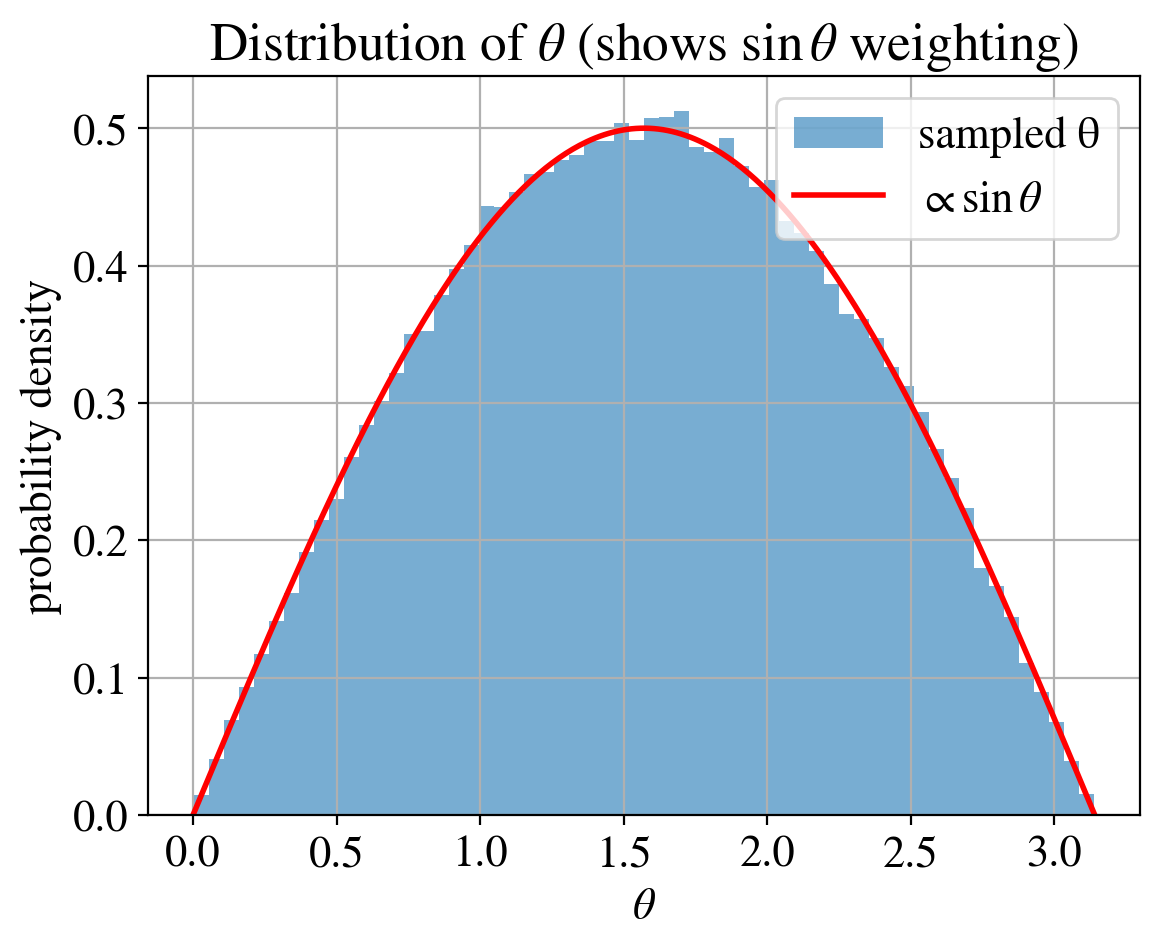

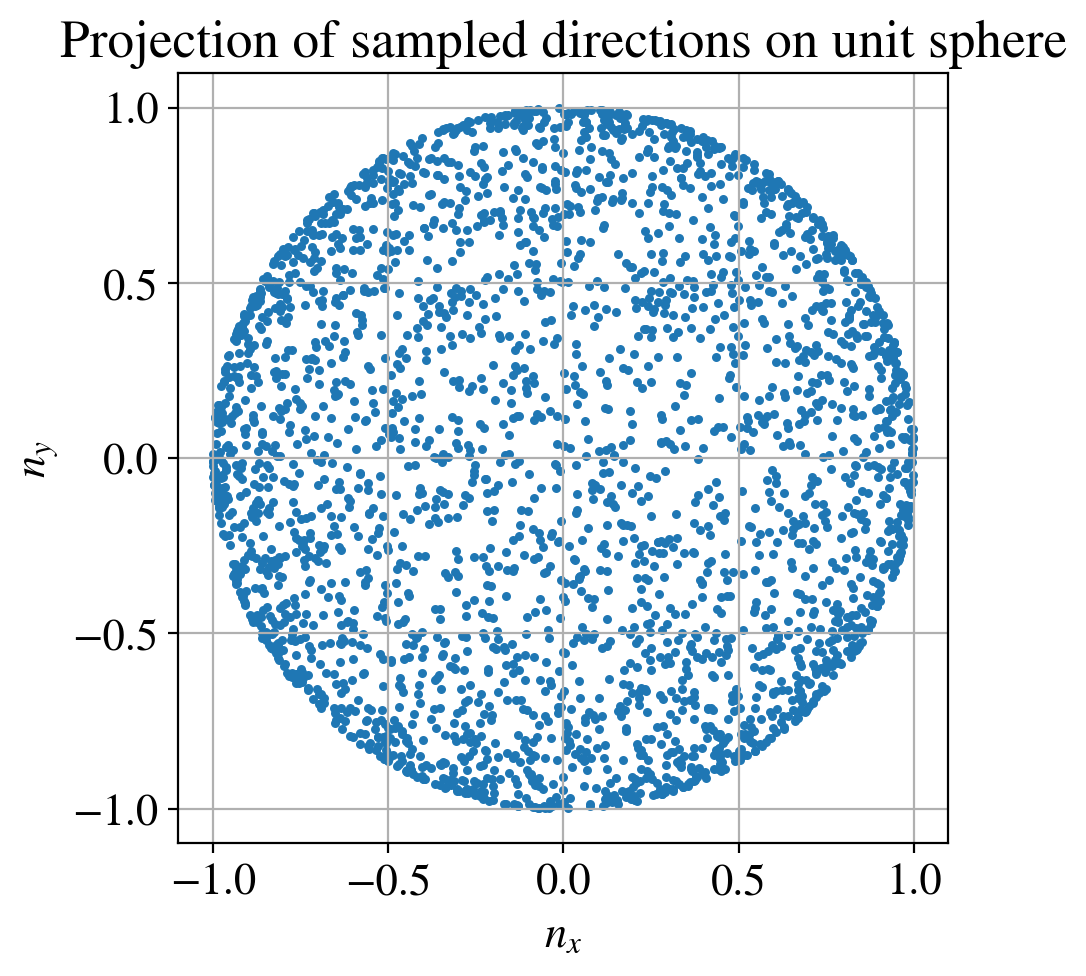

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 椭球参数
# -----------------------------
#a, b, c = 2.0, 1.5, 1.0   # 半轴
a, b, c = 1.0, 1.0, 1.0   # 半轴

N = 200_000
rng = np.random.default_rng(0)

# -----------------------------
# 正确的球面采样（体现 sinθ）
# -----------------------------
u = rng.uniform(-1.0, 1.0, N)      # u = cosθ
phi = rng.uniform(0.0, 2*np.pi, N)

theta = np.arccos(u)

nx = np.sin(theta) * np.cos(phi)
ny = np.sin(theta) * np.sin(phi)
nz = np.cos(theta)

# -----------------------------
# Monte Carlo 表面积估计
# -----------------------------
weights = np.sqrt((a*nx)**2 + (b*ny)**2 + (c*nz)**2)
S_est = 4*np.pi * np.mean(weights)

print(f"Monte Carlo estimate of ellipsoid area ≈ {S_est:.6f}")

# -----------------------------
# 可视化 1：θ 的分布（应 ~ sinθ）
# -----------------------------
plt.figure()
plt.hist(theta, bins=60, density=True, alpha=0.6, label="sampled θ")

t = np.linspace(0, np.pi, 400)
plt.plot(t, 0.5*np.sin(t), 'r', lw=2, label=r"$\propto \sin\theta$")

plt.xlabel(r"$\theta$")
plt.ylabel("probability density")
plt.title(r"Distribution of $\theta$ (shows $\sin\theta$ weighting)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 可视化 2：方向点在球面上的投影
# -----------------------------
plt.figure(figsize=(5,5))
plt.scatter(nx[:3000], ny[:3000], s=5)
plt.gca().set_aspect("equal")
plt.xlabel(r"$n_x$")
plt.ylabel(r"$n_y$")
plt.title("Projection of sampled directions on unit sphere")
plt.grid(True)
plt.show()


## 反函数采样（Inverse Transform Sampling）

### 1. 核心思想

如果你能算出随机变量分布函数 $F(x)$ 的反函数， 那么只要从 $[0,1]$ 上取一个均匀随机数，就能生成该分布的样本。

## 1. 先讲一个最直观的事实：区间概率 = 面积

设随机变量 $X$ 的概率密度为 $f(x)$（密度越高，越“容易出现”）。

某个小区间 $[a,b]$ 被抽中的概率是：

$$
P(a \le X \le b)=\int_a^b f(x)\,dx.
$$

**直觉：**  
- $f(x)$ 在 $[a,b]$ 上越高（“柱子越高”），这段面积越大  
- 面积越大，落在 $[a,b]$ 的概率越大  
- 所以抽样时越容易落进 $[a,b]$

---

## 2. 把“面积”变成“累计直方图/累积分布函数 CDF”

定义累积分布函数（CDF）：

$$
F(x)=P(X\le x)=\int_{-\infty}^{x} f(t)\,dt.
$$

那么区间 $[a,b]$ 的概率就是：

$$
P(a\le X\le b)=F(b)-F(a).
$$

**关键直觉：**  
> 如果 $[a,b]$ 这一段的密度高，那么 $F(x)$ 在 $[a,b]$ 上增长得更快，  
> 于是 $F(b)-F(a)$ 会更大。

也就是说：

- 密度高的区间 → CDF 上对应的“竖直增量”更大  
- 换句话说：在 CDF 的纵轴（0 到 1 的概率刻度）上，这段区间“占的份额更大”

---

## 3. 反函数采样为什么会“更容易落进高密度区间”？

反函数采样做的事是：

1. 先均匀抽一个 $U\sim \mathrm{Uniform}(0,1)$
2. 再令：
   $$
   X = F^{-1}(U).
   $$

现在看区间 $[a,b]$：

- 它在 CDF 上对应的是 $U\in[F(a),F(b)]$
- 这段 $U$ 的长度是：
  $$
  |F(b)-F(a)|.
  $$

因为 $U$ 是在 $[0,1]$ 上均匀抽的，所以：

> $U$ 落入 $[F(a),F(b)]$ 的概率，恰好等于 $F(b)-F(a)$。

而 $U$ 一旦落入这段范围，就一定会得到 $ X \in[a,b] $。

所以你可以把反函数采样理解为：

> **高密度的区间 $[a,b]$**  
> → 在 CDF 上占据更大的概率份额 $[F(a),F(b)]$  
> → 因此更容易被均匀随机的 $U$ 选中  
> → 最终更容易采到 $ X \in [a,b] $

---

## 4. 一句话总结（课堂版）

> **密度高的区间，在 CDF 上“占的概率份额更大”；  
> 反函数采样是先均匀抽概率份额，所以自然更常落进高密度区间。**


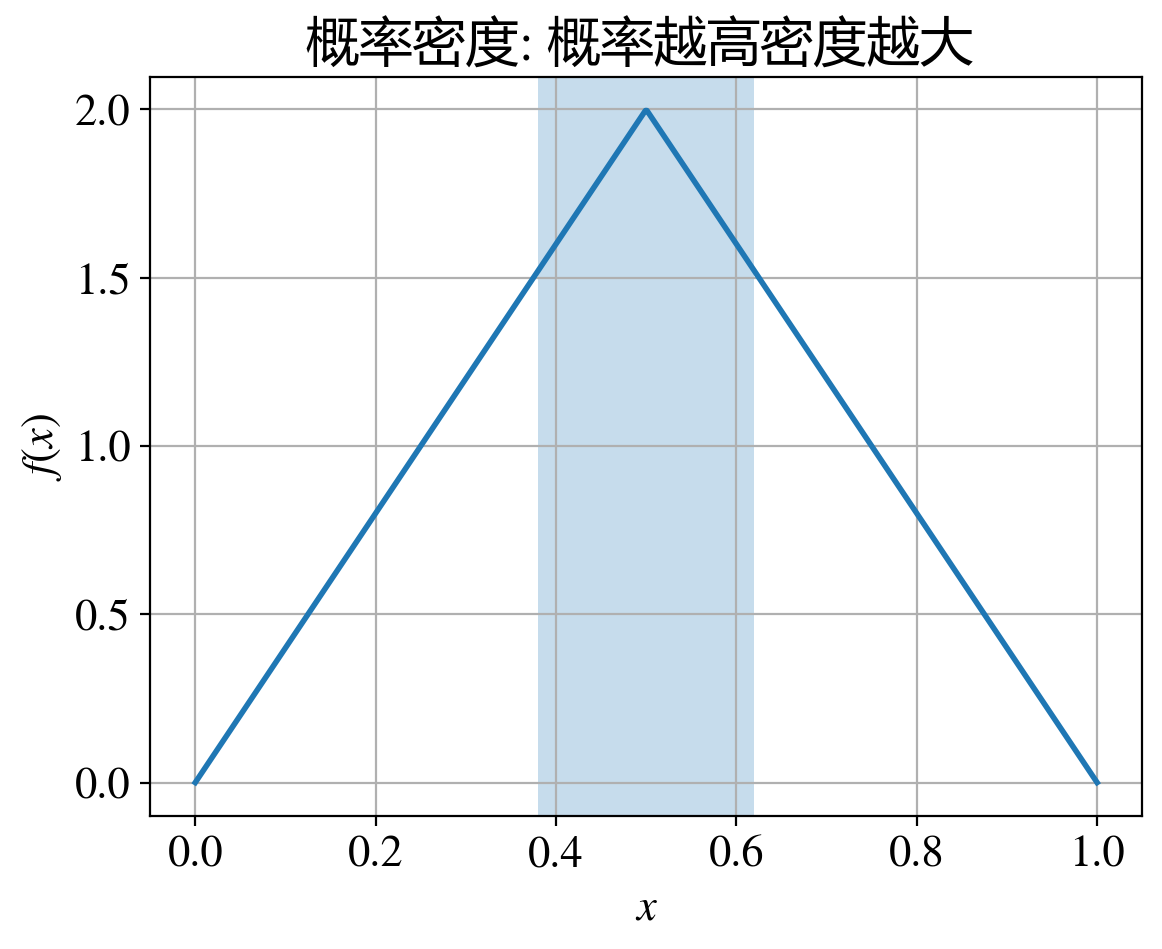

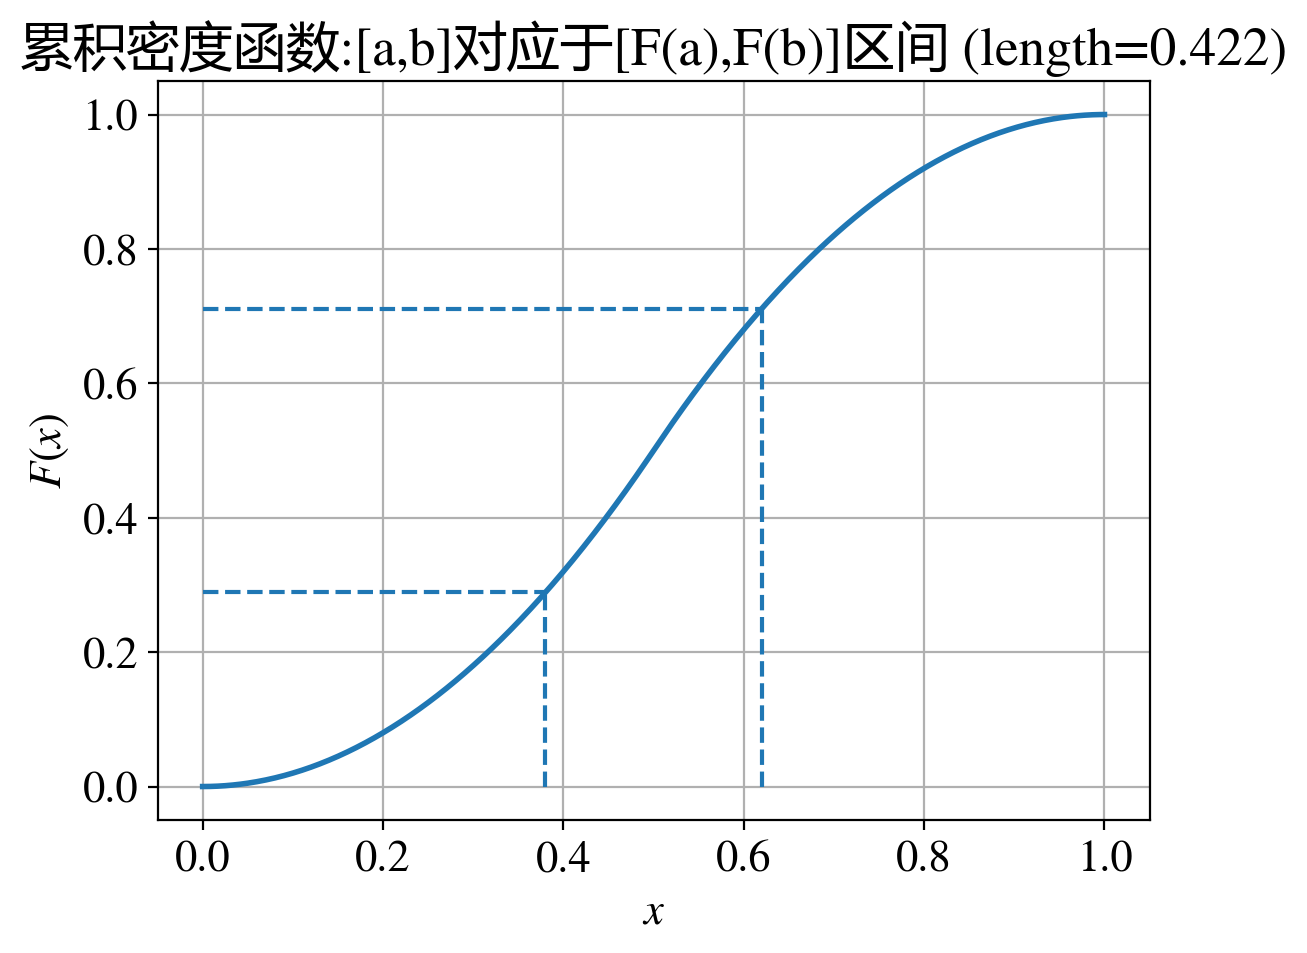

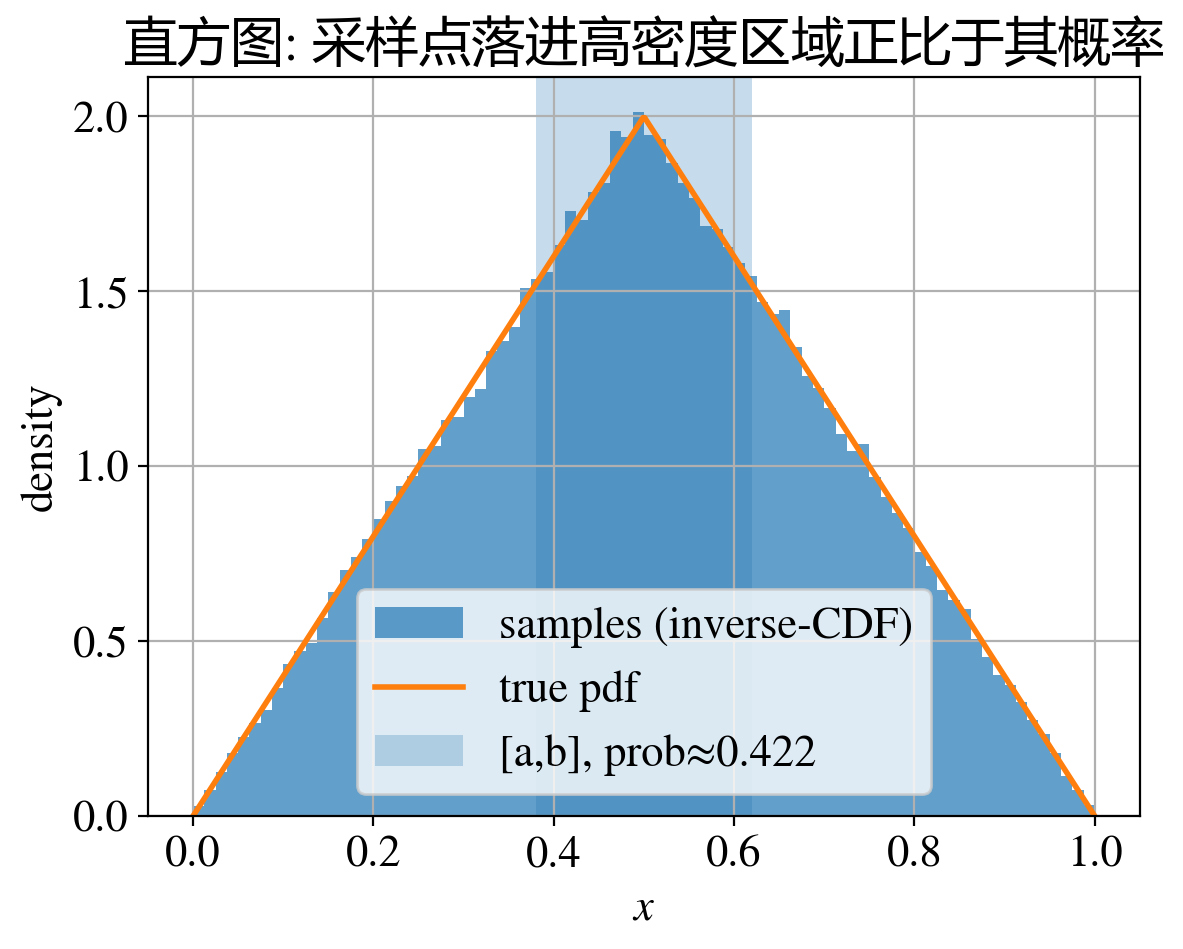

Interval [a,b]=[0.38,0.62]
F(a)=0.2888, F(b)=0.7112, F(b)-F(a)=0.4224
Empirical fraction in [a,b] ≈ 0.4237


In [86]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 用一个“中间更高”的分布演示：三角形分布 Triangular(0, mode, 1)
# 这类分布的直觉很强：中间密度高，两边密度低
# ============================================================

rng = np.random.default_rng(0)

# 分布参数（定义在 [0,1]）
mode = 0.5  # 峰值位置（越靠近中间越对称；靠近右侧表示右侧更“高密度”）
# 选一个区间 [a,b] 来比较
a, b = 0.38, 0.62

# ------------------------------------------------------------
# PDF & CDF（分段写出，便于讲课）
# 三角形分布 Tri(0, mode, 1)
# ------------------------------------------------------------
def pdf_tri(x, m=mode):
    x = np.asarray(x)
    f = np.zeros_like(x, dtype=float)
    left = (0 <= x) & (x <= m)
    right = (m < x) & (x <= 1)
    f[left] = 2*x[left]/m
    f[right] = 2*(1 - x[right])/(1 - m)
    return f

def cdf_tri(x, m=mode):
    x = np.asarray(x)
    F = np.zeros_like(x, dtype=float)
    left = (0 <= x) & (x <= m)
    right = (m < x) & (x <= 1)
    F[left] = (x[left]**2)/m
    F[right] = 1 - ((1 - x[right])**2)/(1 - m)
    F[x < 0] = 0.0
    F[x > 1] = 1.0
    return F

# ------------------------------------------------------------
# 反函数采样（Triangular 的反 CDF 也分段）
# ------------------------------------------------------------
def inv_cdf_tri(u, m=mode):
    u = np.asarray(u)
    x = np.zeros_like(u, dtype=float)
    # F(m) = m
    left = (u <= m)
    right = (u > m)
    x[left] = np.sqrt(u[left] * m)
    x[right] = 1 - np.sqrt((1 - u[right]) * (1 - m))
    
    return x

# 生成样本：反函数采样
N = 200000
U = rng.uniform(0, 1, N)
X = inv_cdf_tri(U, mode)

# ------------------------------------------------------------
# 计算区间概率：P(a<=X<=b) = F(b)-F(a)
# 并画出“在 CDF 上占了多大范围”
# ------------------------------------------------------------
Fa, Fb = cdf_tri(np.array([a, b]), mode)
prob_interval = float(Fb - Fa)

# ------------------------------------------------------------
# 作图：PDF + 选中区间面积；CDF + 对应的 [F(a), F(b)]；样本直方图
# ------------------------------------------------------------
xs = np.linspace(0, 1, 600)
pdf = pdf_tri(xs, mode)
cdf = cdf_tri(xs, mode)

plt.figure()
plt.plot(xs, pdf, linewidth=2)
plt.axvspan(a, b, alpha=0.25)
plt.title("概率密度: 概率越高密度越大 ")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(xs, cdf, linewidth=2)
plt.vlines([a, b], 0, [Fa, Fb], linestyles="--")
plt.hlines([Fa, Fb], 0, [a, b], linestyles="--")
plt.title(f"累积密度函数:[a,b]对应于[F(a),F(b)]区间 (length={prob_interval:.3f})")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.grid(True)
plt.show()

plt.figure()
plt.hist(X, bins=80, range=(0, 1), density=True, alpha=0.7, label="samples (inverse-CDF)")
plt.plot(xs, pdf, linewidth=2, label="true pdf")
plt.axvspan(a, b, alpha=0.25, label=f"[a,b], prob≈{prob_interval:.3f}")
plt.title("直方图: 采样点落进高密度区域正比于其概率")
plt.xlabel("$x$")
plt.ylabel("density")
plt.grid(True)
plt.legend()
plt.show()

print(f"Interval [a,b]=[{a},{b}]")
print(f"F(a)={Fa:.4f}, F(b)={Fb:.4f}, F(b)-F(a)={prob_interval:.4f}")
print(f"Empirical fraction in [a,b] ≈ {np.mean((X>=a)&(X<=b)):.4f}")


#### 已知条件

考虑定义在区间 $[0,1]$ 上的概率密度函数：

$$
f(x) = \sin x, \qquad 0 \le x \le \pi.
$$

累积密度函数?

$$
F(x) = \frac{1}{2} (1 - \cos x), \qquad 0 \le x \le \pi.
$$

反函数?
$$
 x = \arccos( 1 - 2 u ), \qquad u \in [0, 1] 
$$

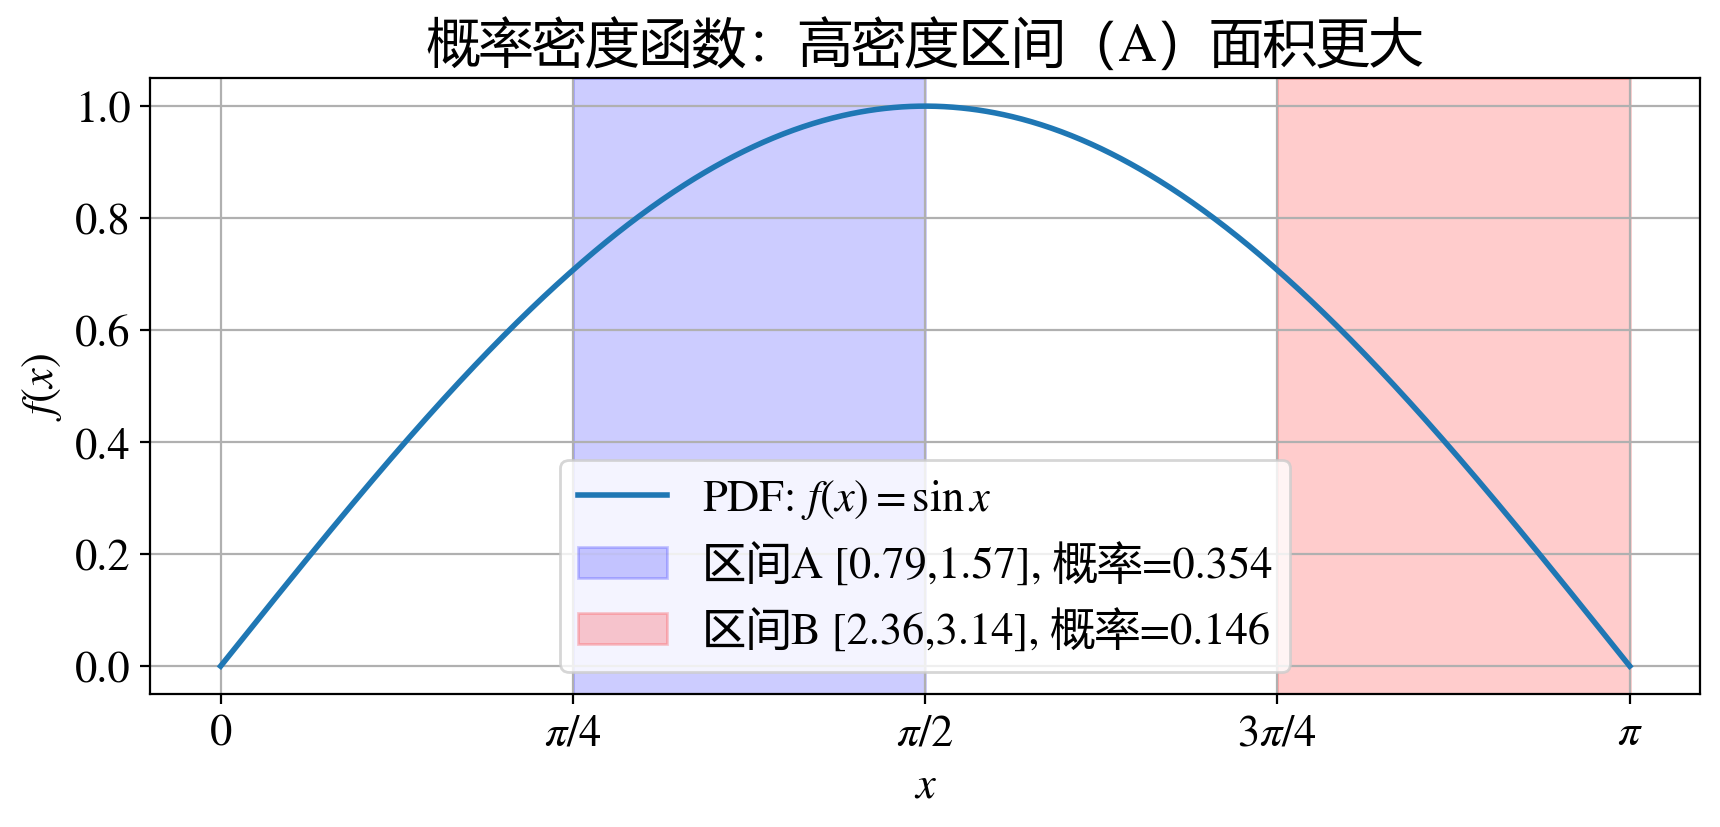

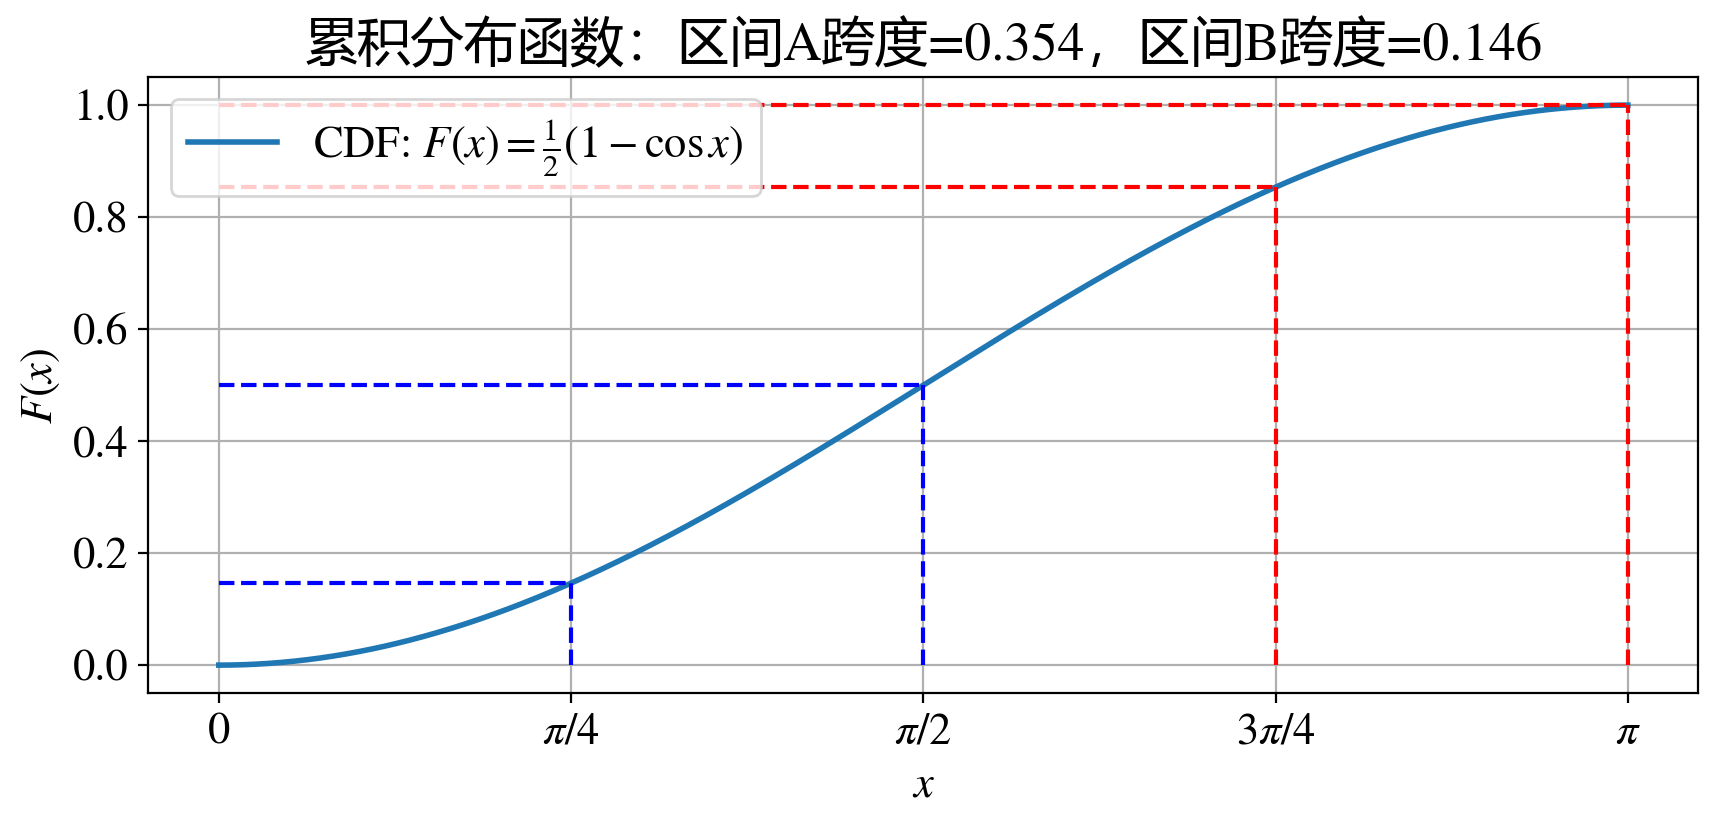

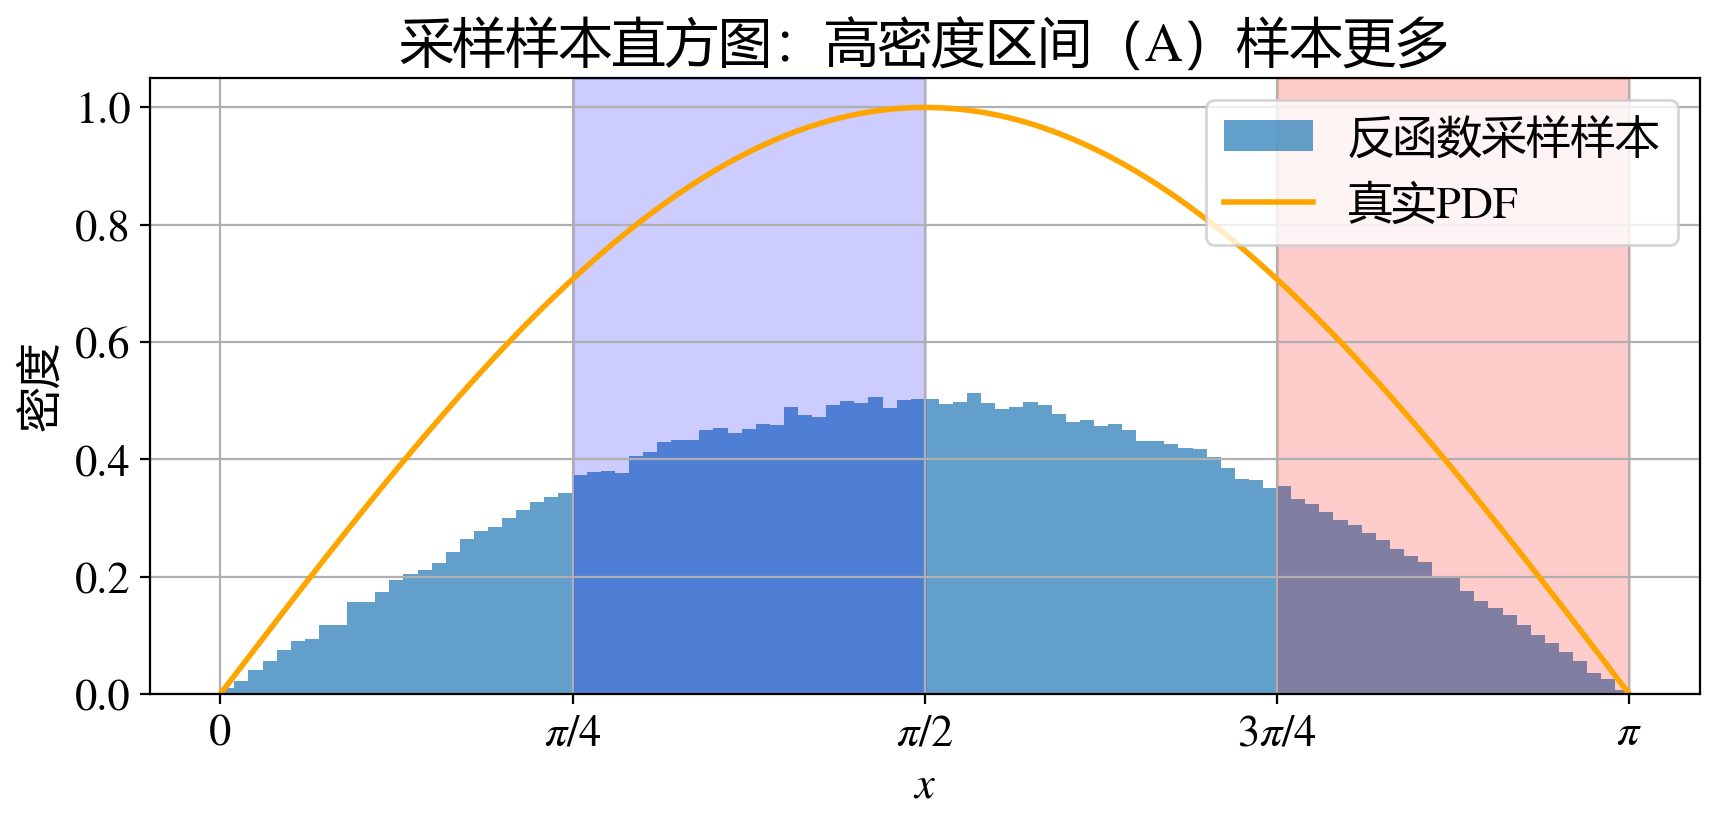

区间A（高密度）：[0.79, 1.57]
  理论概率 = 0.3536 | 实际采样频率 = 0.3540
区间B（低密度）：[2.36, 3.14]
  理论概率 = 0.1464 | 实际采样频率 = 0.1469


In [132]:
import numpy as np
import matplotlib.pyplot as plt

# 初始化随机数生成器（保证结果可复现）
rng = np.random.default_rng(42)

# 分布核心参数（定义域）
x_low, x_high = 0, np.pi

# ========== 1. 定义PDF、CDF、反函数 ==========
def pdf(x):
    """概率密度函数 f(x) = sinx (0 ≤ x ≤ π)"""
    x = np.asarray(x)
    f = np.zeros_like(x, dtype=float)
    # 仅在[0, π]范围内计算sinx，其余为0
    mask = (x_low <= x) & (x <= x_high)
    f[mask] = np.sin(x[mask])
    return f

def cdf(x):
    """累积分布函数 F(x) = (1 - cosx)/2 (0 ≤ x ≤ π)"""
    x = np.asarray(x)
    F = np.zeros_like(x, dtype=float)
    mask = (x_low <= x) & (x <= x_high)
    F[mask] = 0.5 * (1 - np.cos(x[mask]))
    # 边界处理：x>π时CDF=1，x<0时CDF=0
    F[x > x_high] = 1.0
    return F

def inv_cdf(u):
    """反函数采样：x = arccos(1 - 2u) (u ∈ [0,1])"""
    u = np.asarray(u)
    # 关键：确保u在[0,1]内（避免arccos输入超出[-1,1]）
    u_clipped = np.clip(u, 0.0, 1.0)
    return np.arccos(1 - 2 * u_clipped)

# ========== 2. 选择对比区间（验证高密度易被抽到） ==========
# 区间A：π/4 ~ π/2（sinx峰值区，高密度）
a1, b1 = np.pi/4, np.pi/2
# 区间B：3π/4 ~ π（sinx低值区，低密度）
a2, b2 = 3*np.pi/4, np.pi

# ========== 3. 生成反函数采样样本 ==========
N = 200000  # 样本数量（越大越接近真实分布）
U = rng.uniform(0, 1, N)  # 生成[0,1]均匀随机数
X = inv_cdf(U)  # 转换为sinx分布的样本

# ========== 4. 计算理论概率 & 实际采样频率 ==========
# 理论概率（CDF差值）
prob_A = float(cdf(b1) - cdf(a1))
prob_B = float(cdf(b2) - cdf(a2))

# 实际频率（样本落在区间内的比例）
freq_A = np.mean((X >= a1) & (X <= b1))
freq_B = np.mean((X >= a2) & (X <= b2))

# ========== 5. 可视化验证 ==========
# 生成绘图用的x轴数据
xs = np.linspace(x_low, x_high, 1000)
pdf_vals = pdf(xs)
cdf_vals = cdf(xs)

# 图1：PDF + 区间面积（概率）
plt.figure(figsize=(10, 4))
plt.plot(xs, pdf_vals, linewidth=2, label=r"PDF: $f(x)=\sin x$")
plt.axvspan(a1, b1, alpha=0.2, color="blue", label=f"区间A [{a1:.2f},{b1:.2f}], 概率={prob_A:.3f}")
plt.axvspan(a2, b2, alpha=0.2, color="red", label=f"区间B [{a2:.2f},{b2:.2f}], 概率={prob_B:.3f}")
plt.title("概率密度函数：高密度区间（A）面积更大")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], 
           ["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
plt.grid(True)
plt.legend()
plt.show()

# 图2：CDF + 区间对应的概率跨度
plt.figure(figsize=(10, 4))
plt.plot(xs, cdf_vals, linewidth=2, label=r"CDF: $F(x)=\frac{1}{2}(1-\cos x)$")
# 标注区间A的CDF跨度
plt.vlines([a1, b1], 0, cdf([a1, b1]), linestyles="--", color="blue")
plt.hlines(cdf([a1, b1]), 0, [a1, b1], linestyles="--", color="blue")
# 标注区间B的CDF跨度
plt.vlines([a2, b2], 0, cdf([a2, b2]), linestyles="--", color="red")
plt.hlines(cdf([a2, b2]), 0, [a2, b2], linestyles="--", color="red")
plt.title(f"累积分布函数：区间A跨度={prob_A:.3f}，区间B跨度={prob_B:.3f}")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], 
           ["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
plt.grid(True)
plt.legend()
plt.show()

# 图3：采样样本直方图（对比真实PDF）
plt.figure(figsize=(10, 4))
plt.hist(X, bins=100, range=(x_low, x_high), density=True, alpha=0.7, label="反函数采样样本")
plt.plot(xs, pdf_vals, linewidth=2, color="orange", label="真实PDF")
plt.axvspan(a1, b1, alpha=0.2, color="blue")
plt.axvspan(a2, b2, alpha=0.2, color="red")
plt.title("采样样本直方图：高密度区间（A）样本更多")
plt.xlabel("$x$")
plt.ylabel("密度")
plt.xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], 
           ["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
plt.grid(True)
plt.legend()
plt.show()

# ========== 输出关键结果 ==========
print("="*50)
print(f"区间A（高密度）：[{a1:.2f}, {b1:.2f}]")
print(f"  理论概率 = {prob_A:.4f} | 实际采样频率 = {freq_A:.4f}")
print(f"区间B（低密度）：[{a2:.2f}, {b2:.2f}]")
print(f"  理论概率 = {prob_B:.4f} | 实际采样频率 = {freq_B:.4f}")
print("="*50)

### 课堂练习：为什么高密度区间更容易被抽到？

#### 练习目标

通过一个具体的例子，理解：

- 区间 $[a,b]$ 的被抽中概率等于该区间下的**面积**
- 在累积分布函数（CDF）中，高密度区间对应**更大的概率跨度**
- 反函数采样会更容易生成落在高密度区间的样本

---

#### 已知条件

考虑定义在区间 $[0,1]$ 上的概率密度函数：

$$
f(x)=2x,\qquad 0\le x\le 1.
$$

累积密度函数?

反函数?

---

#### 问题 1（纸笔题）

1. 写出对应的累积分布函数 $F(x)$。
2. 计算下列两个区间的概率：
   - 区间 A：$[0.2,\,0.4]$
   - 区间 B：$[0.6,\,0.8]$

**提示：**

$$
P(a\le X\le b)=F(b)-F(a).
$$

思考：  
- 两个区间的长度是否相同？  
- 哪个区间更容易被抽到？为什么？

---

#### 问题 2（直觉题）

虽然区间 A 和区间 B 的长度都是 $0.2$，但它们在 CDF 上对应的“概率跨度”是否相同？

请用一句话解释你的判断。

---

#### 问题 3（上机验证）

利用反函数采样生成随机样本，画出累积直方图。

---

#### Python 骨架代码


### 核心需求理解
你需要针对概率密度函数 $f(x)=2x$（定义在区间 $[0,1]$ 上）完成反函数采样的课堂练习，包括推导累积分布函数（CDF）、计算指定区间的概率、解释高密度区间的概率跨度问题，并用Python代码实现反函数采样和可视化验证，以此理解“高密度区间更容易被抽到”的核心逻辑。

### 一、纸笔题解答（问题1）
#### 1. 推导累积分布函数 $F(x)$
根据CDF的定义：
$$
F(x) = P(X \le x) = \int_{-\infty}^x f(t) dt
$$
由于 $f(x)=2x$ 仅在 $[0,1]$ 上有定义（其余区间为0），因此：
$$
F(x) = \int_0^x 2t dt = t^2 \big|_0^x = x^2 \quad (0 \le x \le 1)
$$
补充完整定义域：
- 当 $x < 0$ 时，$F(x) = 0$；
- 当 $x > 1$ 时，$F(x) = 1$。

#### 2. 计算区间概率
根据公式 $P(a \le X \le b) = F(b) - F(a)$：
- **区间A [0.2, 0.4]**：
  $P(0.2 \le X \le 0.4) = F(0.4) - F(0.2) = 0.4^2 - 0.2^2 = 0.16 - 0.04 = 0.12$。
- **区间B [0.6, 0.8]**：
  $P(0.6 \le X \le 0.8) = F(0.8) - F(0.6) = 0.8^2 - 0.6^2 = 0.64 - 0.36 = 0.28$。

#### 思考解答
- 两个区间的长度均为 $0.2$（长度相同）；
- 区间B更容易被抽到，因为概率密度函数 $f(x)=2x$ 是**随x递增的**，区间B的x值更大，对应的密度更高（比如0.7处密度为1.4，0.3处密度为0.6），因此该区间的概率（面积）更大。

### 二、直觉题解答（问题2）
两个区间长度相同，但在CDF上的“概率跨度”不同（A为0.12，B为0.28）；因为 $f(x)=2x$ 随x增大而增大，区间B的密度更高，CDF在该区间的增长速度更快，因此占据的概率跨度更大。

### 三、上机验证（问题3）
以下是完整的Python代码，包含PDF/CDF定义、反函数采样、可视化验证：


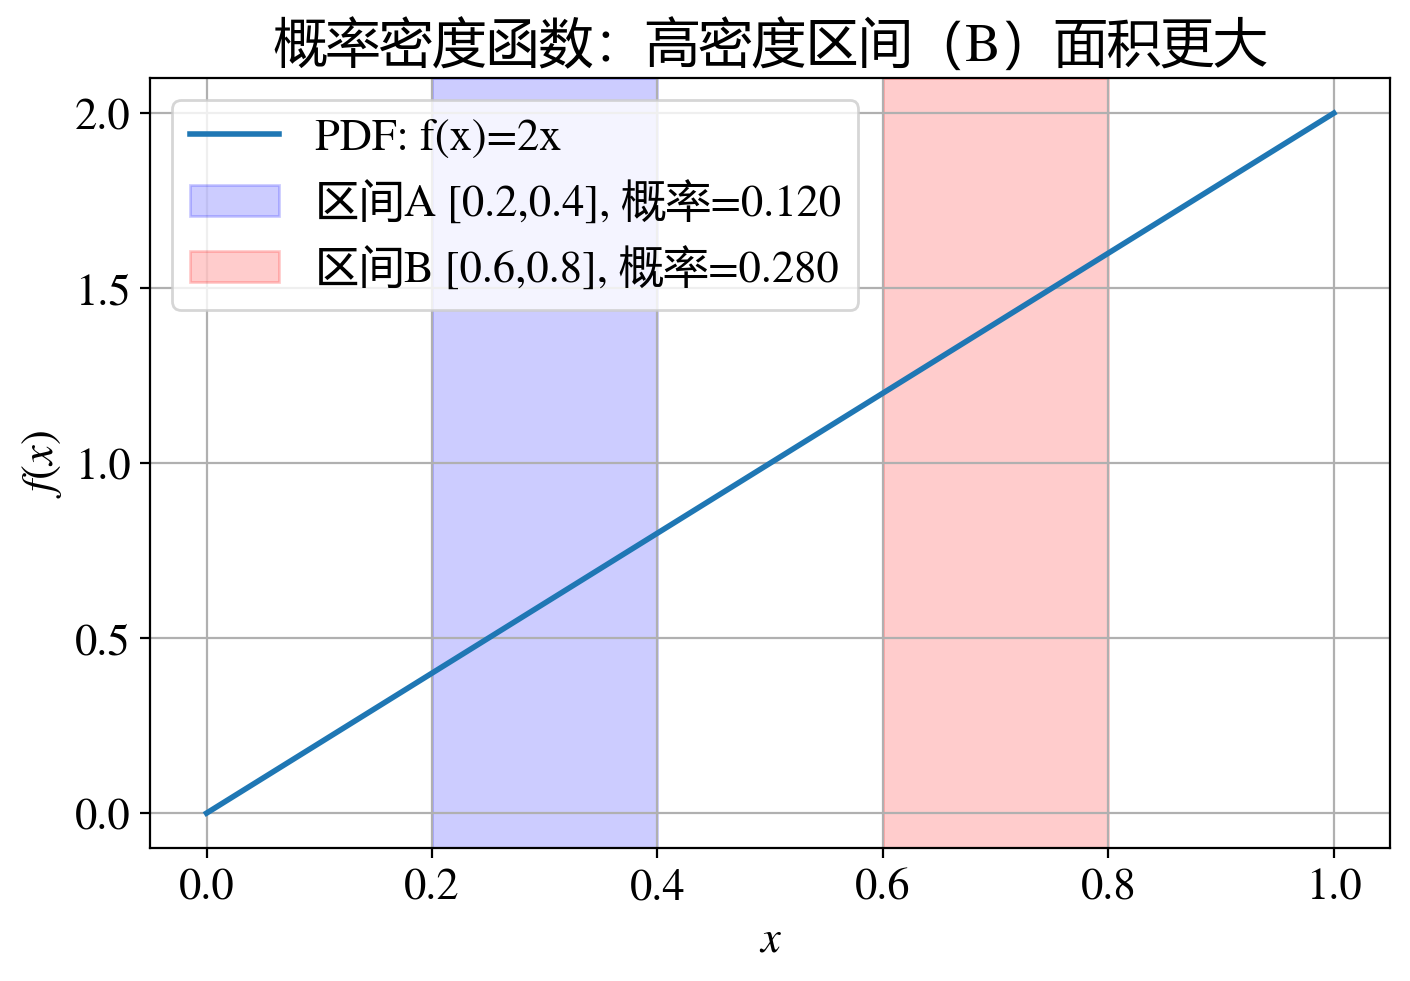

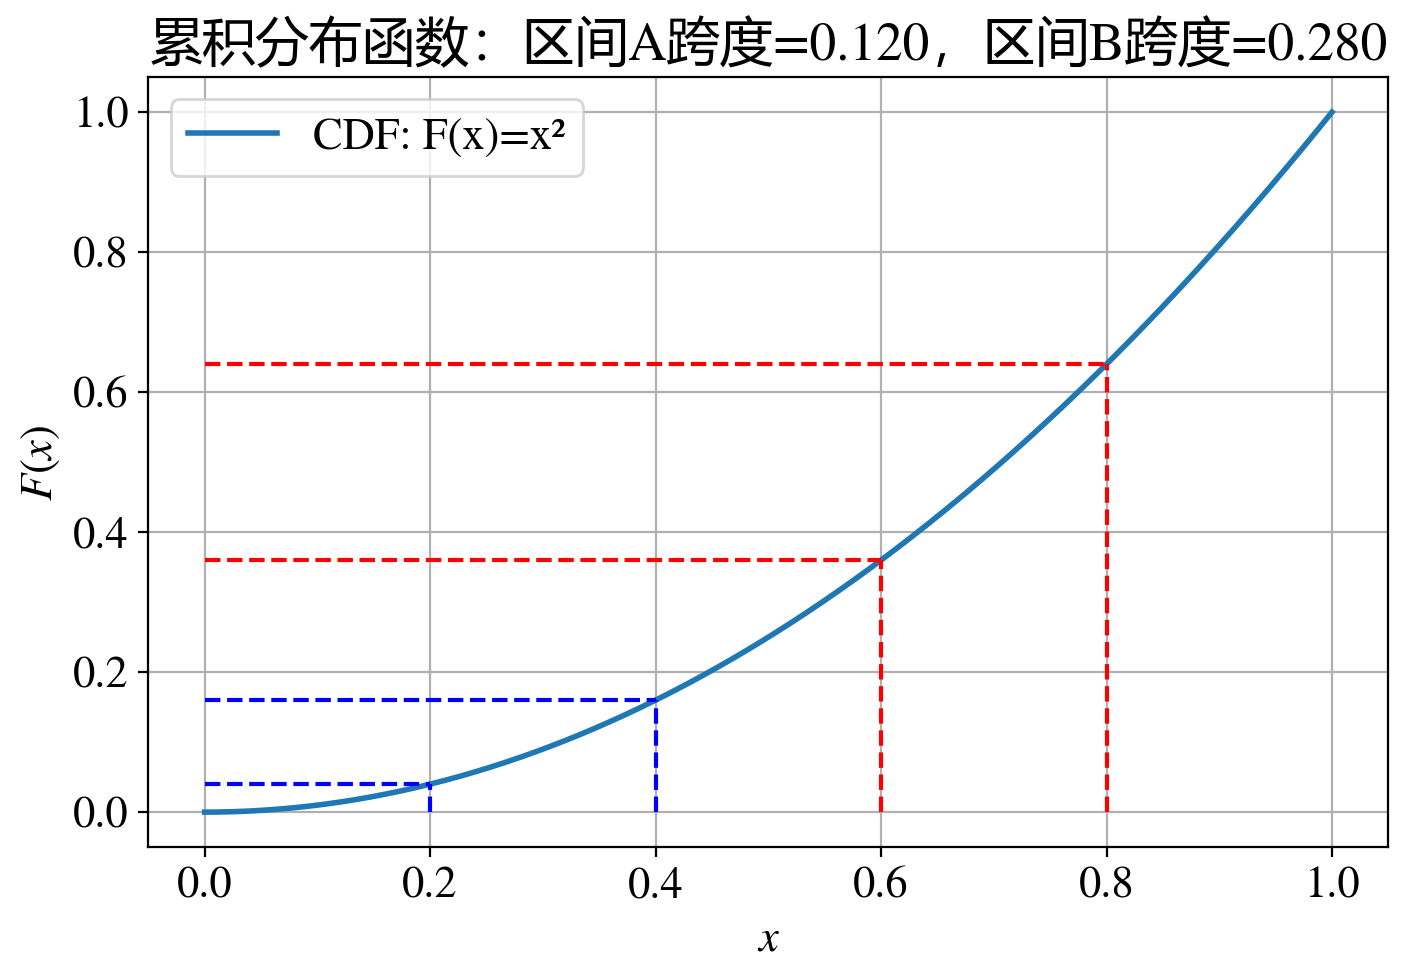

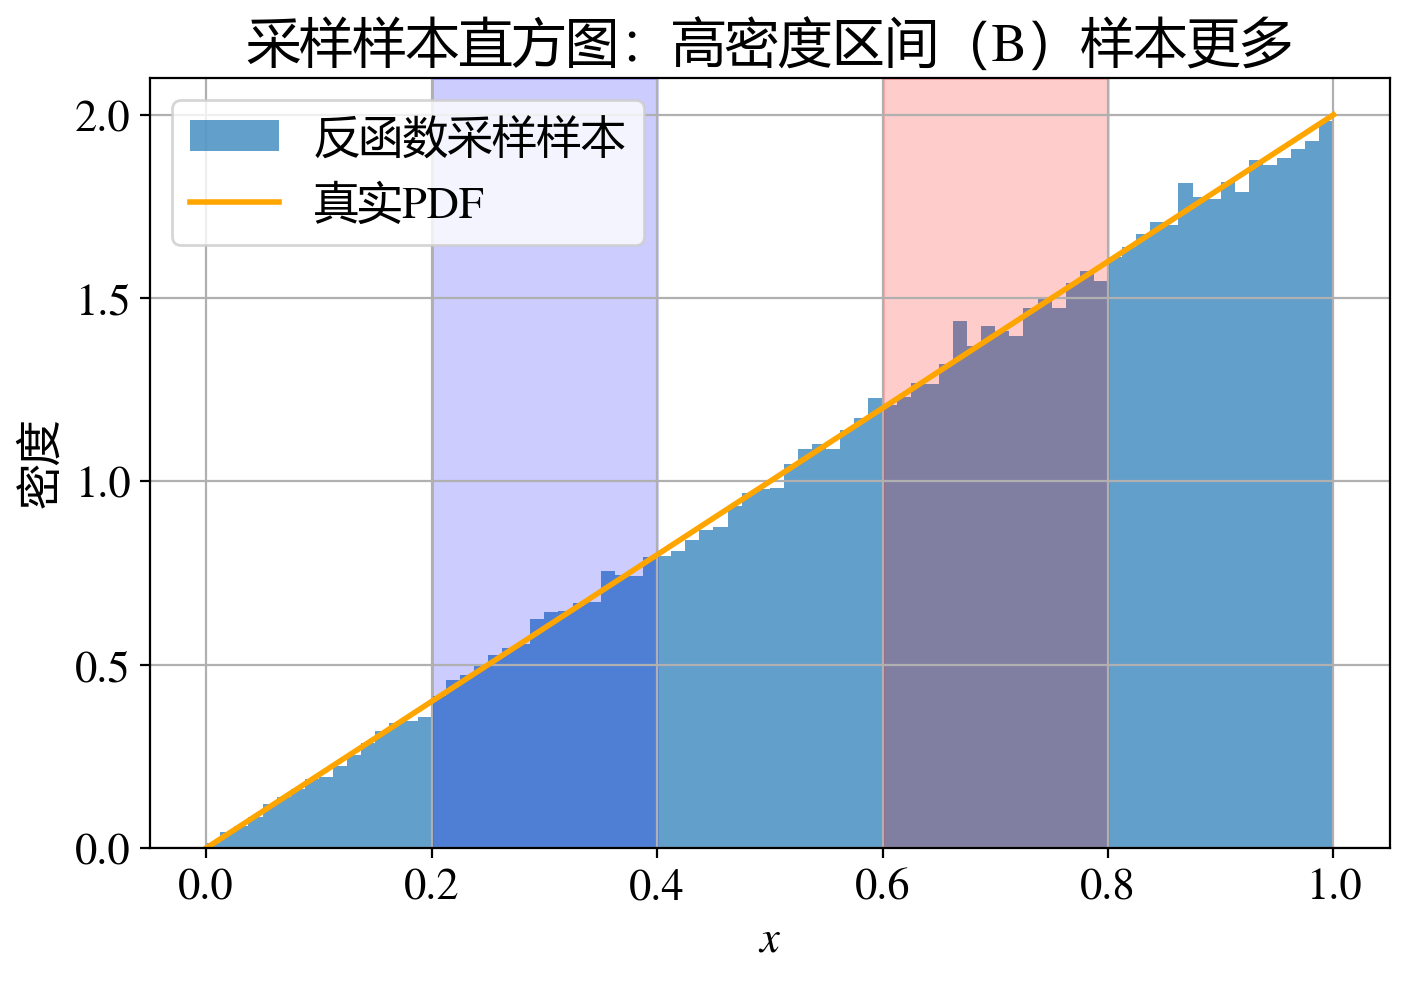

区间A [0.2,0.4]：
  理论概率 = 0.1200，实际采样频率 = 0.1220
区间B [0.6,0.8]：
  理论概率 = 0.2800，实际采样频率 = 0.2805


In [92]:
import numpy as np
import matplotlib.pyplot as plt

# 初始化随机数生成器（保证结果可复现）
rng = np.random.default_rng(0)

# 定义区间A和B
a1, b1 = 0.2, 0.4  # 区间A
a2, b2 = 0.6, 0.8  # 区间B

# ===================== 1. 定义PDF、CDF、反函数 =====================
def pdf(x):
    """概率密度函数 f(x)=2x (0≤x≤1)"""
    x = np.asarray(x)
    f = np.zeros_like(x, dtype=float)
    mask = (0 <= x) & (x <= 1)
    f[mask] = 2 * x[mask]
    return f

def cdf(x):
    """累积分布函数 F(x)=x² (0≤x≤1)"""
    x = np.asarray(x)
    F = np.zeros_like(x, dtype=float)
    mask = (0 <= x) & (x <= 1)
    F[mask] = x[mask] **2
    F[x > 1] = 1.0  # x>1时CDF为1
    return F

def inv_cdf(u):
    """反函数采样：U~Uniform(0,1) → X=√U"""
    u = np.asarray(u)
    # 确保u在[0,1]范围内（防止数值误差）
    u = np.clip(u, 0.0, 1.0)
    return np.sqrt(u)

# ===================== 2. 生成反函数采样样本 =====================
N = 200000  # 样本数量（越大越接近真实分布）
U = rng.uniform(0, 1, N)  # 生成[0,1]均匀随机数
X = inv_cdf(U)  # 反函数采样得到目标分布样本

# ===================== 3. 计算区间概率（理论+实际） =====================
# 理论概率
prob_A = cdf(b1) - cdf(a1)
prob_B = cdf(b2) - cdf(a2)

# 实际采样的频率
freq_A = np.mean((X >= a1) & (X <= b1))
freq_B = np.mean((X >= a2) & (X <= b2))

# ===================== 4. 可视化验证 =====================
xs = np.linspace(0, 1, 600)  # 绘图用的x轴数据
pdf_vals = pdf(xs)
cdf_vals = cdf(xs)

# 图1：PDF + 区间A/B的面积（概率）
plt.figure(figsize=(8, 5))
plt.plot(xs, pdf_vals, linewidth=2, label="PDF: f(x)=2x")
plt.axvspan(a1, b1, alpha=0.2, color="blue", label=f"区间A [{a1},{b1}], 概率={prob_A:.3f}")
plt.axvspan(a2, b2, alpha=0.2, color="red", label=f"区间B [{a2},{b2}], 概率={prob_B:.3f}")
plt.title("概率密度函数：高密度区间（B）面积更大")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(True)
plt.legend()
plt.show()

# 图2：CDF + 区间A/B对应的概率跨度
plt.figure(figsize=(8, 5))
plt.plot(xs, cdf_vals, linewidth=2, label="CDF: F(x)=x²")
# 标注区间A的CDF跨度
plt.vlines([a1, b1], 0, [cdf(a1), cdf(b1)], linestyles="--", color="blue")
plt.hlines([cdf(a1), cdf(b1)], 0, [a1, b1], linestyles="--", color="blue")
# 标注区间B的CDF跨度
plt.vlines([a2, b2], 0, [cdf(a2), cdf(b2)], linestyles="--", color="red")
plt.hlines([cdf(a2), cdf(b2)], 0, [a2, b2], linestyles="--", color="red")
plt.title(f"累积分布函数：区间A跨度={prob_A:.3f}，区间B跨度={prob_B:.3f}")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.grid(True)
plt.legend()
plt.show()

# 图3：采样样本的直方图（对比真实PDF）
plt.figure(figsize=(8, 5))
plt.hist(X, bins=80, range=(0, 1), density=True, alpha=0.7, label="反函数采样样本")
plt.plot(xs, pdf_vals, linewidth=2, color="orange", label="真实PDF")
plt.axvspan(a1, b1, alpha=0.2, color="blue")
plt.axvspan(a2, b2, alpha=0.2, color="red")
plt.title("采样样本直方图：高密度区间（B）样本更多")
plt.xlabel("$x$")
plt.ylabel("密度")
plt.grid(True)
plt.legend()
plt.show()

# ===================== 输出结果 =====================
print(f"区间A [{a1},{b1}]：")
print(f"  理论概率 = {prob_A:.4f}，实际采样频率 = {freq_A:.4f}")
print(f"区间B [{a2},{b2}]：")
print(f"  理论概率 = {prob_B:.4f}，实际采样频率 = {freq_B:.4f}")

## 高维 Monte Carlo、重要性采样与方差降低

> 本节课目标  
> 1) 理解 Monte Carlo 为什么在**高维**更有优势  
> 2) 掌握 **重要性采样（Importance Sampling）** 的基本公式与直觉  
> 3) 建立一个关键观念：**方差才是关键**（不是“公式多复杂”）

---

### 1. 高维积分：为什么“传统网格法”会崩？

我们想算一个 $d$ 维积分：

$$
I=\int_{\Omega\subset\mathbb{R}^d} f(\mathbf{x})\,d\mathbf{x}.
$$

#### 1.1 网格法的维数灾难（Curse of Dimensionality）

假设每个维度取 $m$ 个网格点，则总点数是：

$$
m^d.
$$

例如：

- $d=2, m=100$：$100^2=10^4$（还行）
- $d=10, m=100$：$100^{10}=10^{20}$（完全不可行）

> 结论：网格法在高维会被点数爆炸拖垮。

---

### 2. Monte Carlo 的基本公式：积分 = “平均值 × 区域体积”

如果在 $\Omega$ 上均匀随机取点：

$$
\mathbf{X}\sim \mathrm{Uniform}(\Omega),
$$

则有：

$$
I = |\Omega|\,\mathbb{E}[f(\mathbf{X})].
$$

用样本均值近似期望：

$$
\boxed{
\hat I_N = |\Omega|\frac{1}{N}\sum_{i=1}^N f(\mathbf{x}_i),
\quad \mathbf{x}_i\sim \mathrm{Uniform}(\Omega)
}
$$

#### 2.1 误差与收敛

若 $Y=f(\mathbf{X})$，方差为 $\sigma^2=\mathrm{Var}(Y)$，则：

$$
\mathrm{Var}(\hat I_N)=|\Omega|^2\frac{\sigma^2}{N}.
$$

所以典型误差大小：

$$
\boxed{
\text{error}\sim \frac{|\Omega|\sigma}{\sqrt{N}}
}
$$

注意：**误差的幂次是 $1/\sqrt{N}$，与维数 $d$ 没直接出现**。

> 这就是 Monte Carlo 在高维的优势：  
> **它不会因为维数增加而让“必须的采样数”指数爆炸**。

---

### 3. 为什么说“方差才是关键”？

看上面的误差式子：

$$
\text{error}\propto \sigma.
$$

- $N$ 变大：误差按 $1/\sqrt{N}$ 变小（慢但稳定）
- 但如果我们能让 $\sigma$ 变小，误差会立刻变小

> **方差越小，同样的 $N$ 下结果越稳定。**  
> 所以 MC 的核心不是“采更多点”那么简单，而是：  
> **想办法让方差变小（方差降低）。**

---

## 4. 重要性采样（Importance Sampling）：让点“去该去的地方”

### 4.1 普通均匀采样的问题

很多积分的贡献集中在某个区域（例如尖峰、尾部），  
但均匀采样会在“没贡献的地方”浪费大量样本 → 方差大。

---

### 4.2 重要性采样公式（重点）

我们要计算：

$$
I=\int_{\mathbb{R}^d} f(\mathbf{x})\,d\mathbf{x}.
$$

选一个“更容易采样”的概率密度 $p(\mathbf{x})$（要求 $p>0$ 在重要区域），改写：

$$
I=\int \frac{f(\mathbf{x})}{p(\mathbf{x})}\,p(\mathbf{x})\,d\mathbf{x}
= \mathbb{E}_{\mathbf{X}\sim p}\left[\frac{f(\mathbf{X})}{p(\mathbf{X})}\right].
$$

Monte Carlo 估计量：

$$
\boxed{
\hat I_N^{(\mathrm{IS})}=
\frac{1}{N}\sum_{i=1}^N \frac{f(\mathbf{x}_i)}{p(\mathbf{x}_i)},
\quad \mathbf{x}_i\sim p(\mathbf{x})
}
$$

---

### 4.3 重要性采样的直觉（非常重要）

- 你希望抽样分布 $p(\mathbf{x})$ 在“贡献大的区域”更密集
- 理想情况下：$p(\mathbf{x}) \propto |f(\mathbf{x})|$（这是最优直觉）
- 这样 $\frac{f}{p}$ 不会忽大忽小 → 方差降低

> **重要性采样的本质：用更聪明的抽样，让方差变小。**

---

## 5. 两个代表性例子（带 Python）

下面两例都展示：  
- 普通抽样（方差大 / 偏差大）  
- 重要性采样（方差明显降低）

---

### 例 1：一维尾部积分（展示“别在没用区域浪费样本”）

计算：

$$
I=\int_0^{\infty} e^{-x}\cos(5x)\,dx.
$$

这个积分有解析值（用于对照）：

$$
I=\frac{1}{1+25}=\frac{1}{26}.
$$

思路：
- 用指数分布 $p(x)=e^{-x}$ 做重要性采样很自然  
- 因为 $e^{-x}$ 正是尾部权重，避免截断

---

### 例 2：高维高斯型积分（展示“高维优势 + 方差关键”）

计算：

$$
I_d=\int_{\mathbb{R}^d} \exp(-\|\mathbf{x}\|^2)\,d\mathbf{x}
= \pi^{d/2}.
$$

用 $p(\mathbf{x})$ 取多维正态（重要性采样）可显著减少方差。

---

## 6. 小结

1. 高维下，网格法点数 $m^d$ 爆炸 → 不可行  
2. Monte Carlo 误差 $\sim 1/\sqrt{N}$，不直接随维数指数恶化  
3. MC 的“好坏”主要由方差 $\sigma^2$ 决定  
4. 重要性采样：用 $p(\mathbf{x})$ 把样本集中到贡献大的区域 → 方差降低


In [94]:
# ============================================================
# 工具：重复实验估计“估计量的方差”，用来比较方法好坏
# ============================================================

def repeat_estimator(estimator_fn, R=200, seed=0):
    rng = np.random.default_rng(seed)
    vals = np.array([estimator_fn(rng) for _ in range(R)])
    return vals.mean(), vals.std(ddof=1)

# ============================================================
# 例 1：I = ∫_0^∞ e^{-x} cos(5x) dx = 1/26
#   - 方法A：截断后在 [0,L] 均匀采样（有截断偏差 + 方差可能较大）
#   - 方法B：重要性采样 x ~ Exp(1)（自然覆盖无穷区间）
# ============================================================

true_I = 1/26
L = 20.0
N = 50000

def est_uniform_trunc(rng):
    x = rng.uniform(0, L, size=N)
    fx = np.exp(-x) * np.cos(5*x)
    return L * np.mean(fx)  # 近似 ∫_0^L

def est_importance_exp(rng):
    # p(x)=e^{-x}, x ~ Exp(1)
    x = rng.exponential(scale=1.0, size=N)
    p = np.exp(-x)
    f = np.exp(-x) * np.cos(5*x)
    w = f / p               # = cos(5x)
    return np.mean(w)       # 直接估计 ∫_0^∞

muA, stdA = repeat_estimator(est_uniform_trunc, R=300, seed=20251219)
muB, stdB = repeat_estimator(est_importance_exp, R=300, seed=20251219)

print("=== Example 1: tail integral ===")
print("True I =", true_I)
print(f"Uniform[0,L], L={L}: mean={muA:.6f}, std={stdA:.6f}  (bias from truncation)")
print(f"IS with Exp(1):     mean={muB:.6f}, std={stdB:.6f}  (no truncation)")


=== Example 1: tail integral ===
True I = 0.038461538461538464
Uniform[0,L], L=20.0: mean=0.038566, std=0.010436  (bias from truncation)
IS with Exp(1):     mean=0.038794, std=0.003218  (no truncation)



=== Example 2: d=2 ===
True = 3.141592653589793
IS estimate: mean=3.14159, std=4.45e-16, rel_std~1.42e-16

=== Example 2: d=5 ===
True = 17.493418327624862
IS estimate: mean=17.4934, std=3.23e-15, rel_std~1.84e-16

=== Example 2: d=10 ===
True = 306.0196847852814
IS estimate: mean=306.02, std=5.58e-14, rel_std~1.82e-16


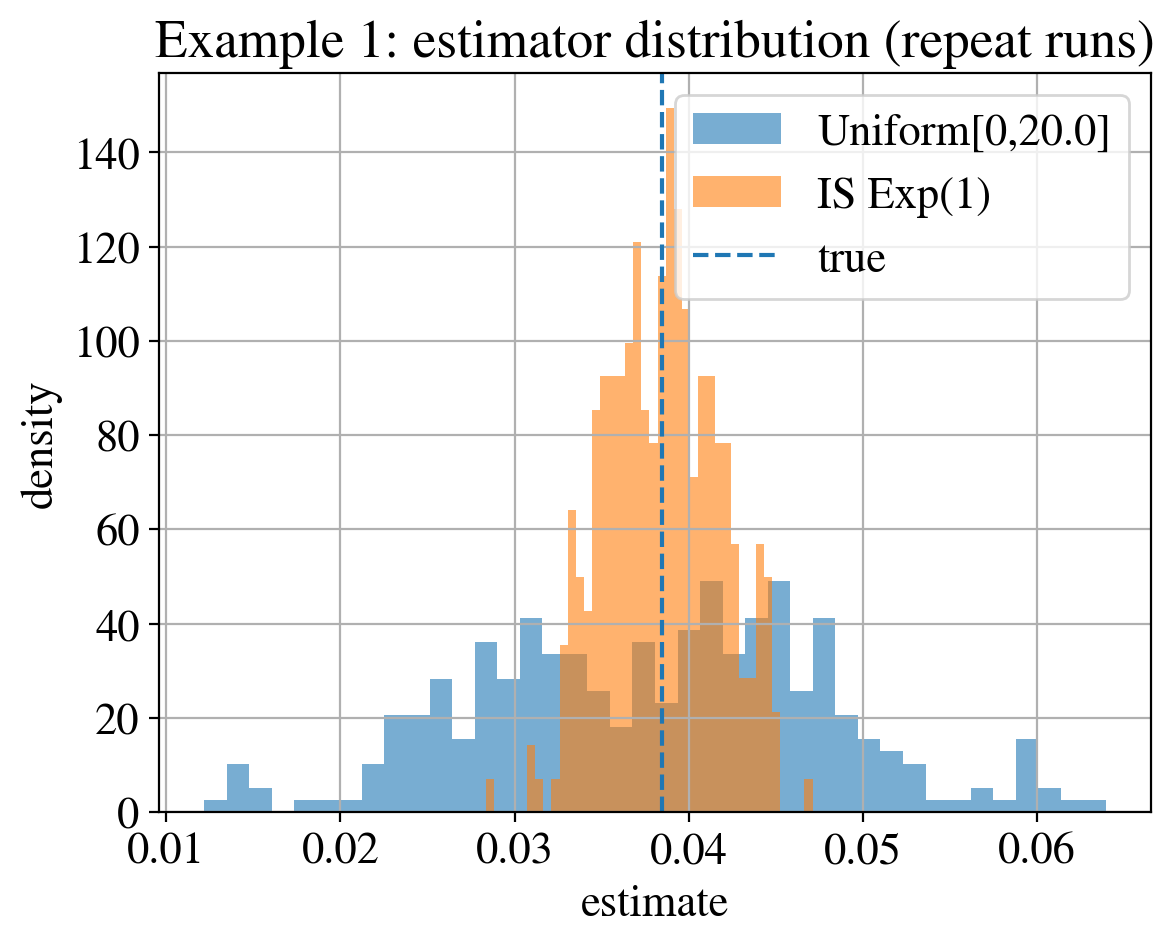

In [95]:
# ============================================================
# 例 2：高维积分 Id = ∫_{R^d} exp(-||x||^2) dx = pi^{d/2}
# 方案：
#   - 重要性采样：用多维正态采样
#     取 p(x) = N(0, (1/2)I) 的密度，则 exp(-||x||^2) 与 p 很匹配
# ============================================================

def gaussian_logpdf(x, sigma2):
    # x: (..., d)
    d = x.shape[-1]
    return -0.5*d*np.log(2*np.pi*sigma2) - np.sum(x*x, axis=-1)/(2*sigma2)

def est_highdim_is(rng, d=10, N=20000, sigma2=0.5):
    # x ~ N(0, sigma2 I)
    x = rng.normal(0.0, np.sqrt(sigma2), size=(N, d))
    f = np.exp(-np.sum(x*x, axis=1))              # exp(-||x||^2)
    logp = gaussian_logpdf(x, sigma2)             # log p(x)
    p = np.exp(logp)
    w = f / p
    return np.mean(w)

for d in [2, 5, 10]:
    true = (np.pi)**(d/2)
    def est_fn(rng, d=d):
        return est_highdim_is(rng, d=d, N=6000, sigma2=0.5)
    mu, sd = repeat_estimator(est_fn, R=200, seed=2)
    print(f"\n=== Example 2: d={d} ===")
    print("True =", true)
    print(f"IS estimate: mean={mu:.6g}, std={sd:.3g}, rel_std~{sd/abs(mu):.3g}")

# ============================================================
# 可视化（例1）：两种方法的重复结果分布
# ============================================================

def collect(estimator_fn, R=300, seed=0):
    rng = np.random.default_rng(seed)
    return np.array([estimator_fn(rng) for _ in range(R)])

A = collect(est_uniform_trunc, R=300, seed=3)
B = collect(est_importance_exp, R=300, seed=3)

plt.figure()
plt.hist(A, bins=40, alpha=0.6, density=True, label=f"Uniform[0,{L}]")
plt.hist(B, bins=40, alpha=0.6, density=True, label="IS Exp(1)")
plt.axvline(true_I, linestyle="--", label="true")
plt.title("Example 1: estimator distribution (repeat runs)")
plt.xlabel("estimate")
plt.ylabel("density")
plt.grid(True)
plt.legend()
plt.show()

## 从 Monte Carlo 到 Markov Chain Monte Carlo（MCMC）

> 本讲目标  
> 1️⃣ 理解：**为什么普通 Monte Carlo 不够用**  
> 2️⃣ 掌握：**Markov Chain Monte Carlo 的基本思想**  
> 3️⃣ 理解：**Metropolis 算法在“干什么”**  
> 4️⃣ 建立：**MCMC 与贝叶斯统计的自然联系**

---

### 1. 回顾：普通 Monte Carlo 在做什么？

在前面的课程中，我们用 Monte Carlo 计算积分：

$$
I = \int f(x)\,dx
$$

通过构造一个**容易采样的分布** $p(x)$，写成期望：

$$
I = \mathbb{E}_{x\sim p}\!\left[\frac{f(x)}{p(x)}\right]
\approx \frac{1}{N}\sum_{i=1}^N \frac{f(x_i)}{p(x_i)}.
$$

关键前提是：

> **我们能从 $p(x)$ 中独立采样（i.i.d.）**

---

### 2. 普通 Monte Carlo 的“瓶颈”在哪里？

#### 2.1 现实问题中，$p(x)$ 往往很难采样

在很多实际问题中，我们面对的是：

- 高维分布（几十、上百维）
- 分布形状复杂（多峰、强相关）
- 只有“相对权重”，没有归一化常数

例如：

$$
p(x) \propto e^{-V(x)}
$$

其中积分

$$
Z=\int e^{-V(x)}dx
$$

**根本算不出来**。

👉 这时：
- 我们能算 $p(x_1)/p(x_2)$
- 但**不能直接从 $p(x)$ 抽独立样本**

---

#### 2.2 重要问题转述

我们真正需要的是：

> **“只要样本最终服从目标分布就行，不一定独立。”**

这正是 MCMC 的出发点。

---

### 3. Markov Chain Monte Carlo 的核心思想

#### 3.1 什么是 Markov Chain？

一个随机序列 $\{X_0,X_1,X_2,\dots\}$ 是 Markov 链，如果：

$$
P(X_{n+1}|X_n,X_{n-1},\dots)=P(X_{n+1}|X_n)
$$

即：

> **未来只依赖现在，不依赖过去**

---

#### 3.2 MCMC 的基本想法（一句话）

> **构造一个马尔可夫链，使它的“平稳分布”正好是我们想要的 $p(x)$。**

然后：

- 跑得足够久
- 丢掉初始阶段（burn-in）
- 后面的样本就可以当作来自 $p(x)$

---

### 4. Metropolis 算法（最经典的 MCMC）

#### 4.1 算法要解决的问题

给定目标分布：

$$
\pi(x) \propto \text{(已知函数)}
$$

- 不需要知道归一化常数
- 只需能计算 $\pi(x_1)/\pi(x_2)$

---

#### 4.2 Metropolis 算法步骤（重点）

设当前状态为 $x$。

**第 1 步：提出新状态（proposal）**

从一个简单分布中提议：

$$
x' \sim q(x'|x)
$$

例如：

$$
x' = x + \epsilon,\quad \epsilon\sim\mathcal{N}(0,\sigma^2).
$$

---

**第 2 步：计算接受概率**

$$
\alpha = \min\left(1,\frac{\pi(x')}{\pi(x)}\right)
$$

---

**第 3 步：接受或拒绝**

- 以概率 $\alpha$ 接受 $x'$
- 否则停留在原地 $x$

---

#### 4.3 关键直觉（必须讲清楚）

- 如果 $x'$ 让 $\pi(x)$ **变大** → 一定接受
- 如果 $\pi(x')$ **变小** → 仍有概率接受
- 这样可以：
  - 避免卡在局部极大值
  - 保证长期分布正确

---

### 5. 为什么 Metropolis 能“采对分布”？

原因在于一个重要性质：

#### 5.1 细致平衡（Detailed Balance）

Metropolis 算法满足：

$$
\pi(x)\,P(x\to x') = \pi(x')\,P(x'\to x)
$$

这保证：

> **$\pi(x)$ 是该马尔可夫链的平稳分布**

因此，链跑久了以后：

$$
X_n \sim \pi(x).
$$

---

### 6. 用 MCMC 计算期望（回到 Monte Carlo）

一旦有了来自 $\pi(x)$ 的样本：

$$
x_1,x_2,\dots,x_N \sim \pi(x),
$$

就可以估计期望：

$$
\mathbb{E}_{\pi}[f(x)]
\approx \frac{1}{N}\sum_{i=1}^N f(x_i).
$$

注意：

- 样本不独立（有相关性）
- 但**大数定律仍然成立**

---

### 7. MCMC 与贝叶斯统计的自然联系

#### 7.1 贝叶斯公式

给定数据 $D$ 和参数 $\theta$：

$$
p(\theta|D)
= \frac{p(D|\theta)\,p(\theta)}{p(D)}.
$$

其中：

- $p(\theta|D)$：后验分布（最关心）
- $p(D)$：证据（通常难算）

---

#### 7.2 MCMC 的关键优势

在 MCMC 中：

$$
p(\theta|D) \propto p(D|\theta)\,p(\theta)
$$

- **不需要计算 $p(D)$**
- 只需要知道后验的“相对大小”

这正是 Metropolis 接受率中：

$$
\frac{\pi(\theta')}{\pi(\theta)}
$$

的来源。

---

### 7.3 贝叶斯推断中的 MCMC 流程

1. 写出后验分布（到比例常数）
2. 用 MCMC 从后验采样
3. 用样本：
   - 算均值、方差
   - 给置信区间（credible interval）
   - 看参数相关性

---

### 8. 普通 Monte Carlo vs MCMC（对比总结）

| | 普通 Monte Carlo | MCMC |
|--|--|--|
| 采样 | 独立样本 | Markov 链 |
| 需要归一化？ | 通常需要 | 不需要 |
| 高维相关 | 很难 | 很自然 |
| 误差 | $1/\sqrt{N}$ | $1/\sqrt{N_{\text{eff}}}$ |

---

### 9. 总结

> - Monte Carlo：我**能直接采样**  
> - MCMC：我**不能直接采样，但能算相对概率**  
> - Metropolis：通过“接受 / 拒绝”机制，  
>   让 Markov 链的长期分布等于目标分布  
> - 贝叶斯统计：后验分布几乎都靠 MCMC 来算

---

## 10. 下一步你将看到什么？

- Metropolis–Hastings（非对称 proposal）
- Gibbs 采样
- 高维下的采样效率问题
- 与物理、统计、机器学习的联系


=== Experiment 1: Standard Normal ===
accept rate = 0.7063166666666667
mean ≈ 0.007019950470493011
var  ≈ 0.9995291300332051


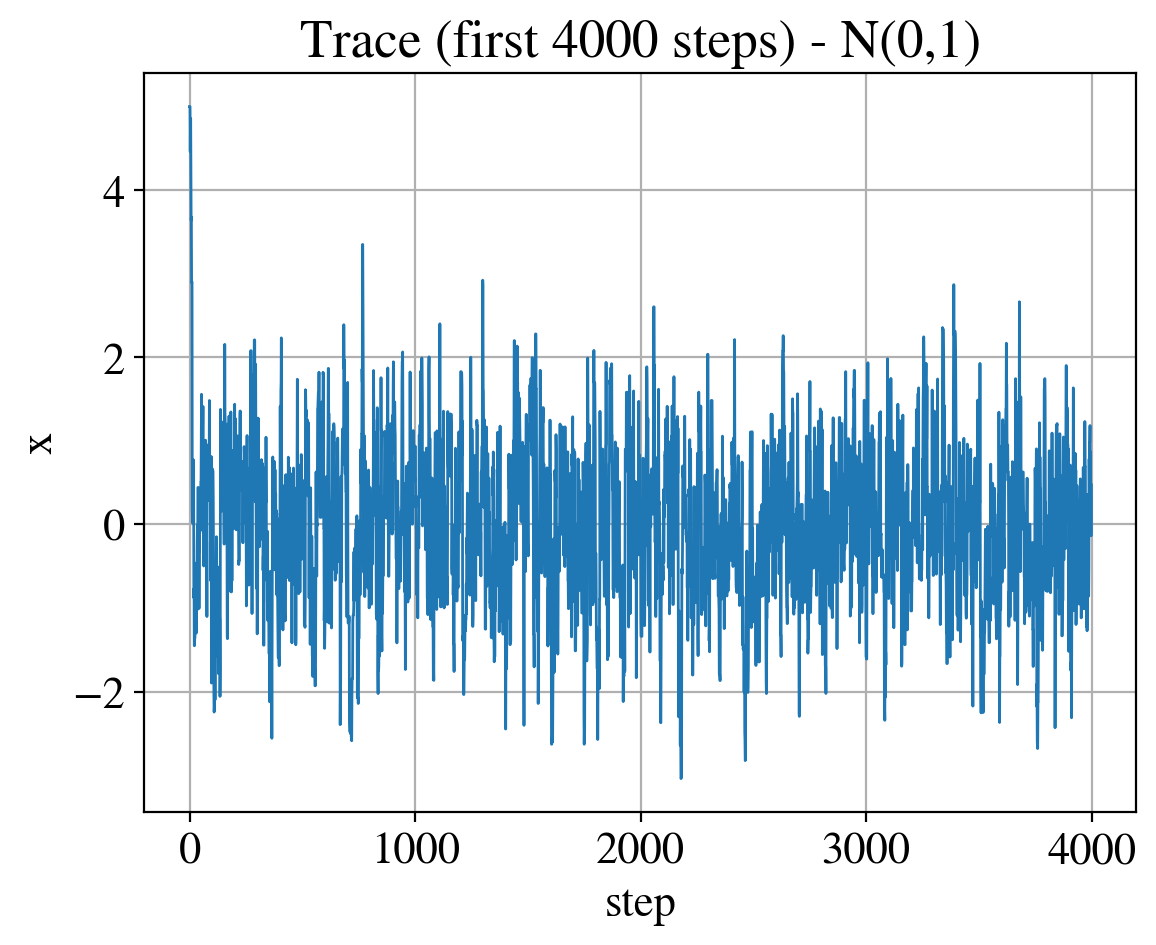

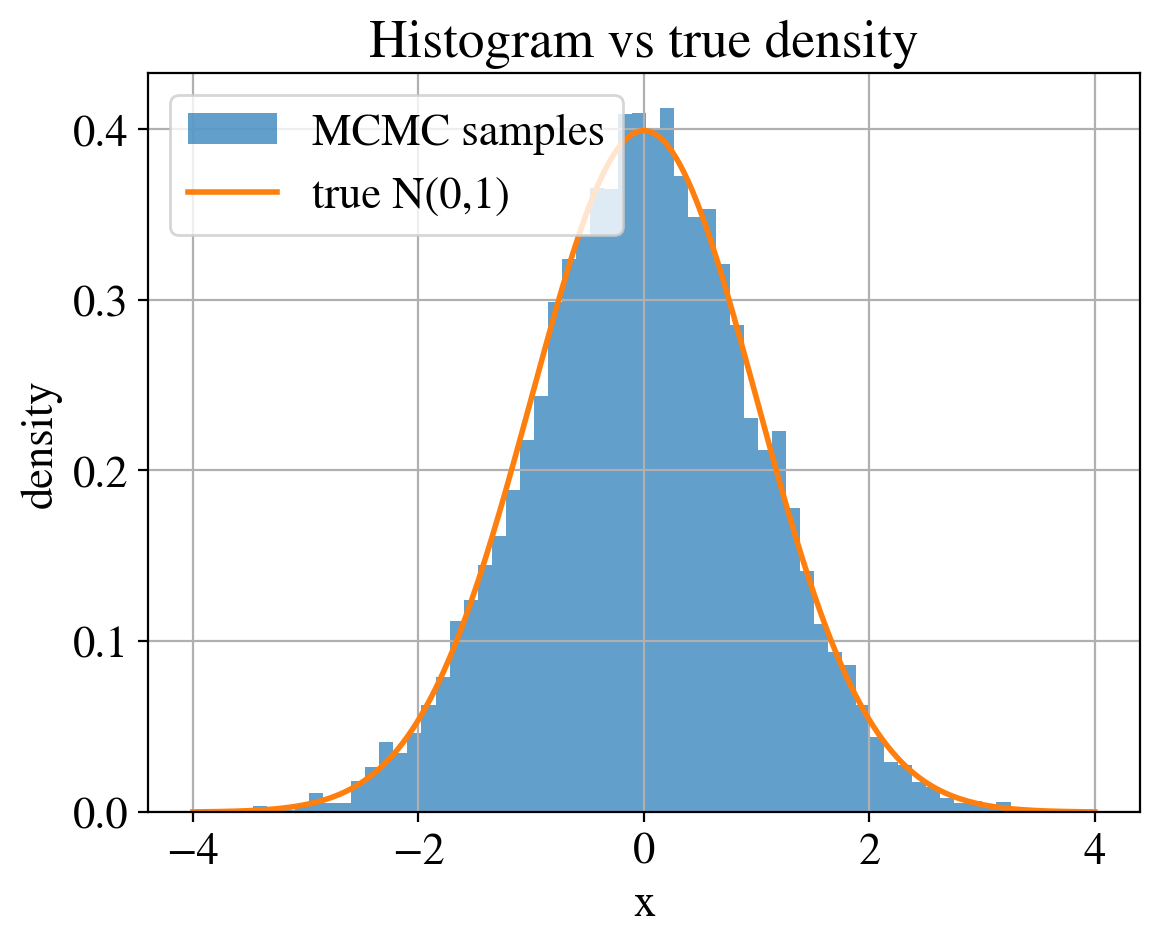

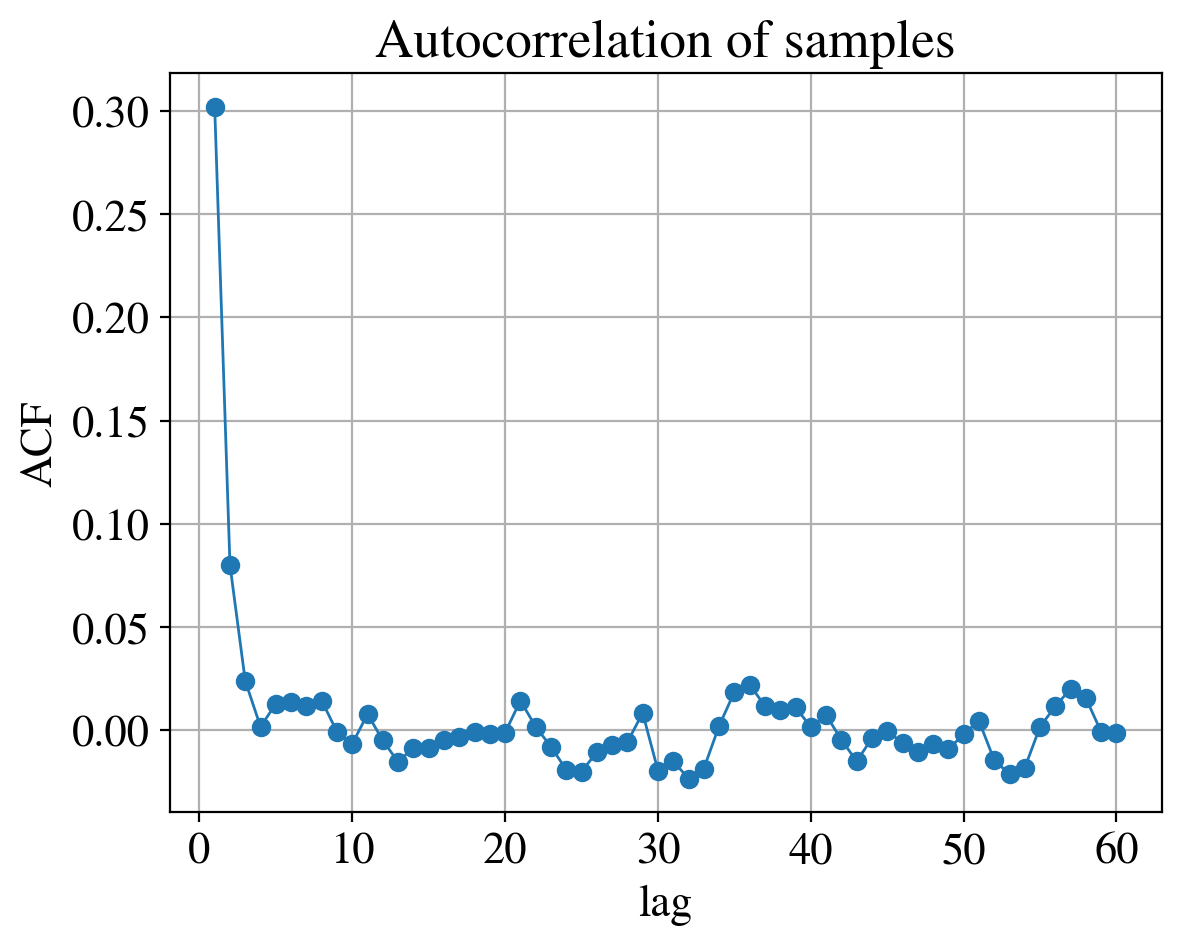


=== Experiment 2: Tuning proposal_std ===
proposal_std=0.2  accept=0.937  sample_std≈1.021
proposal_std=0.5  accept=0.845  sample_std≈1.020
proposal_std=1.0  accept=0.707  sample_std≈0.993
proposal_std=2.0  accept=0.503  sample_std≈0.998
proposal_std=3.0  accept=0.377  sample_std≈0.997


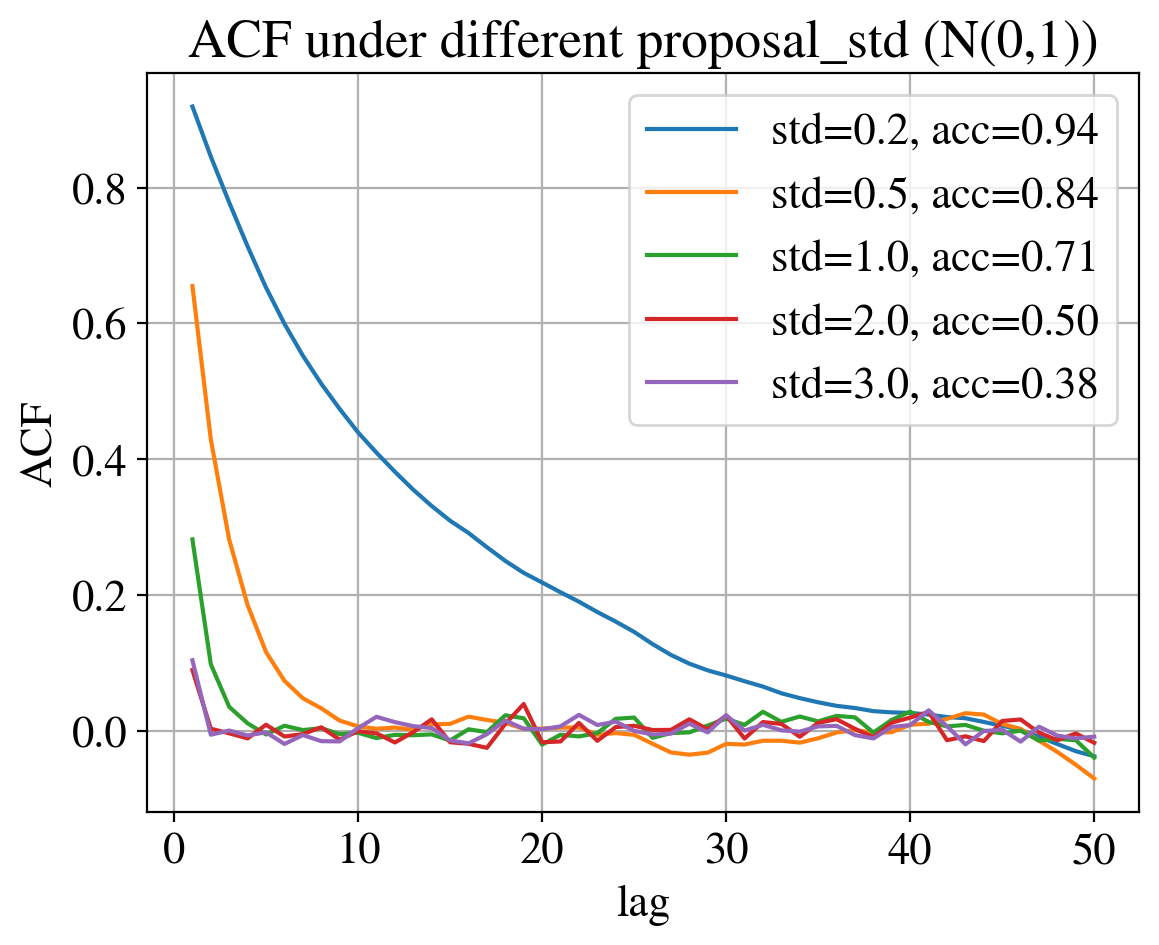


=== Experiment 3: Bimodal, proposal_std=0.5 ===
accept rate = 0.8471875
fraction x>0 = 0.5217857142857143


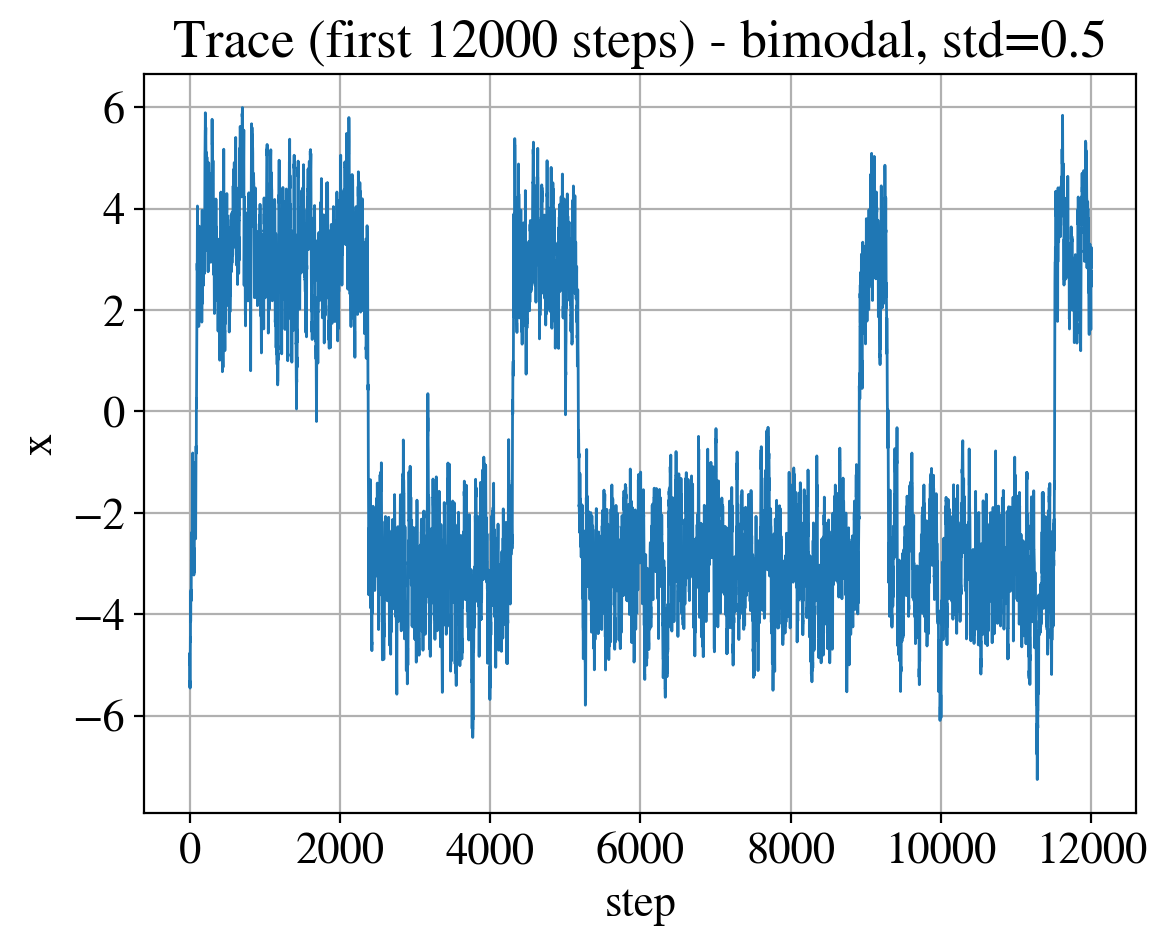

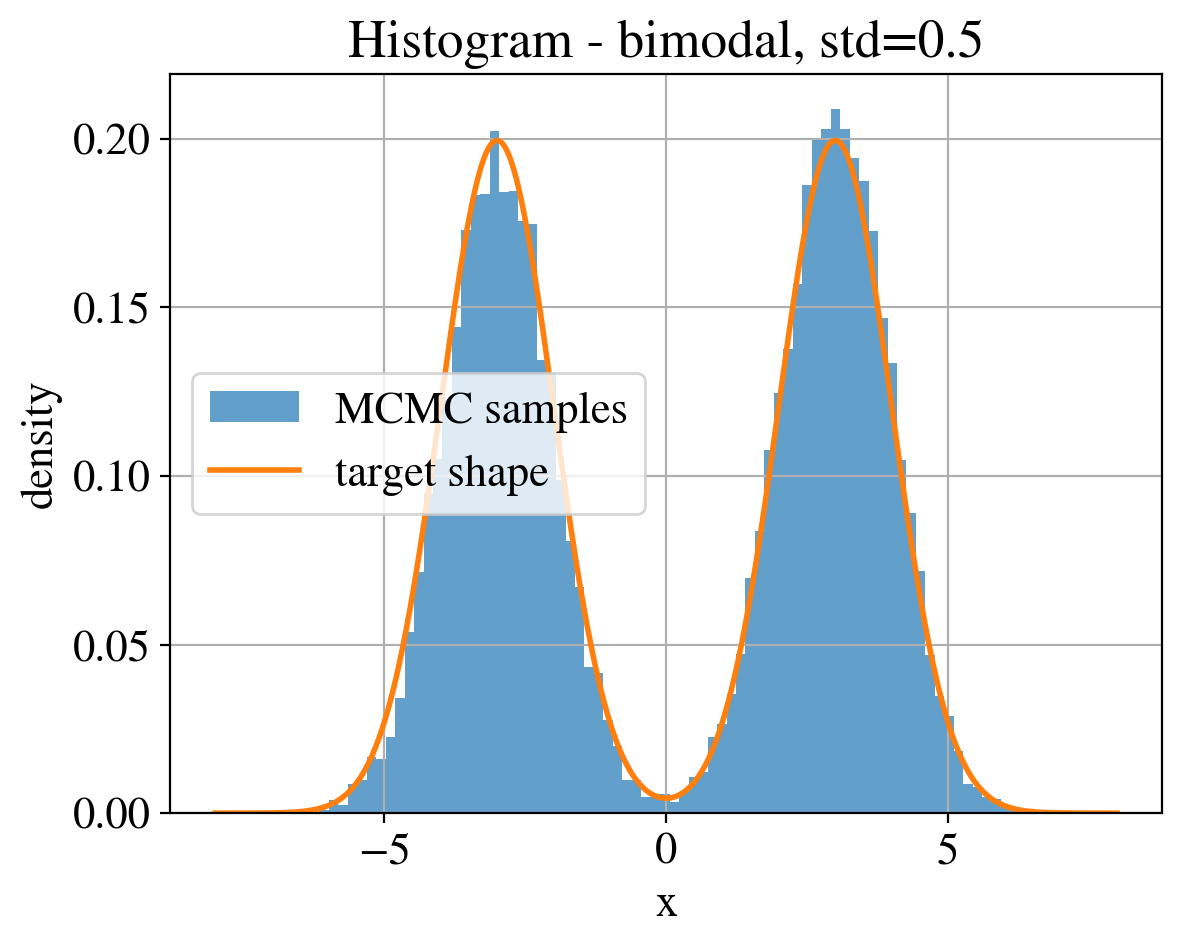


=== Experiment 3: Bimodal, proposal_std=2.0 ===
accept rate = 0.5305
fraction x>0 = 0.502


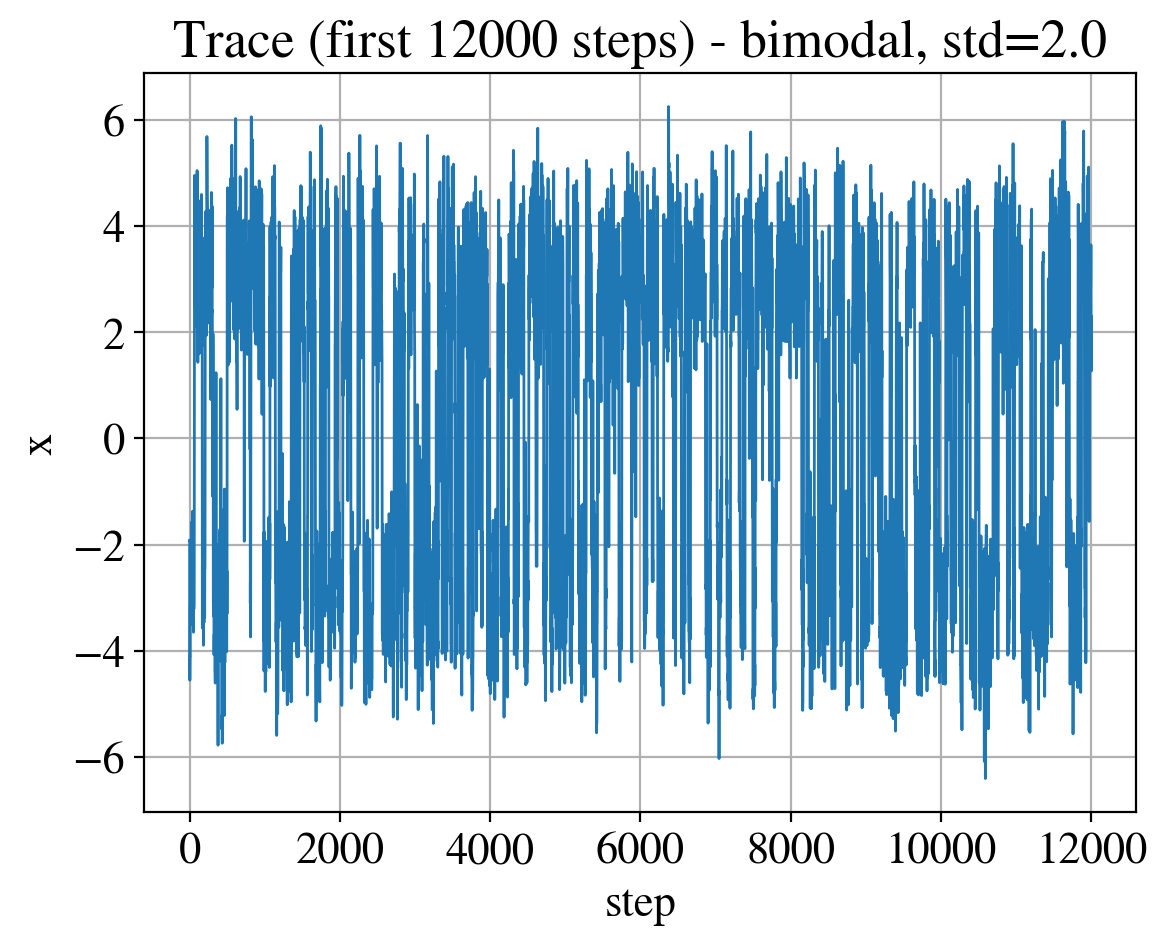

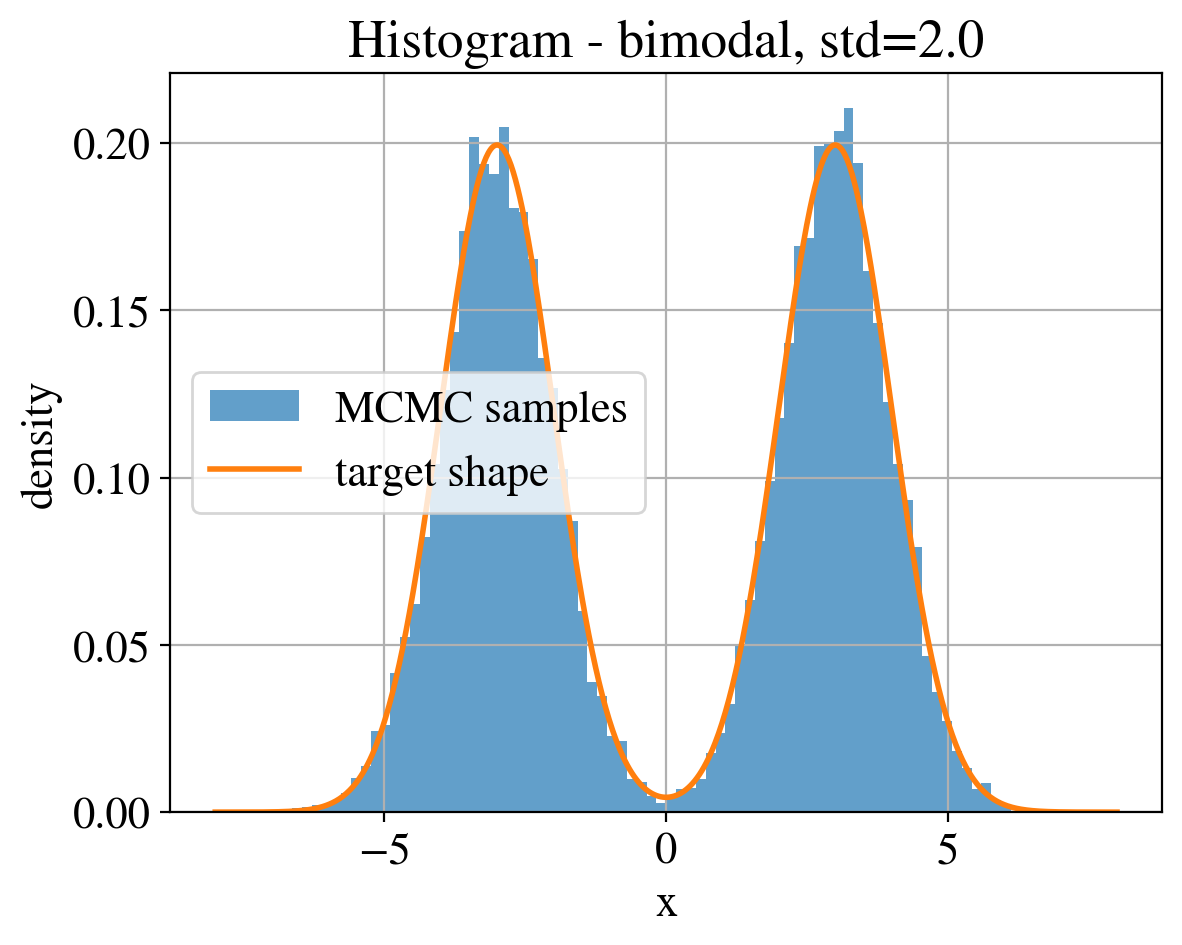


=== Experiment 4: Estimating expectations ===
Estimate E[X^2] ≈ 0.9995784097378134 (true = 1)


In [97]:

# -----------------------------
# 1) Metropolis 采样器（通用）
# -----------------------------
def metropolis(logpi, x0, n_steps=50_000, proposal_std=1.0,
               burn=2_000, thin=1, seed=0):
    """
    Metropolis sampler for 1D target pi(x) (given by logpi up to constant).

    Parameters
    ----------
    logpi : callable
        log target density up to additive constant.
    x0 : float
        initial state.
    n_steps : int
        total MCMC steps (including burn-in).
    proposal_std : float
        proposal step size sigma for random-walk: x' = x + N(0, sigma^2).
    burn : int
        burn-in steps to discard.
    thin : int
        keep one sample every 'thin' steps after burn.
    seed : int
        random seed.

    Returns
    -------
    samples : np.ndarray
    acc_rate : float
        acceptance rate over all steps.
    chain : np.ndarray
        full chain (for trace plots).
    """
    rng = np.random.default_rng(seed)
    x = float(x0)
    logp = float(logpi(x))
    chain = np.empty(n_steps)
    accepts = 0

    for i in range(n_steps):
        # propose
        x_new = x + rng.normal(0.0, proposal_std)
        logp_new = float(logpi(x_new))

        # accept/reject using log form
        if np.log(rng.uniform()) < (logp_new - logp):
            x, logp = x_new, logp_new
            accepts += 1

        chain[i] = x

    acc_rate = accepts / n_steps

    # collect samples after burn with thinning
    if burn >= n_steps:
        raise ValueError("burn must be < n_steps")
    samples = chain[burn::thin].copy()
    return samples, acc_rate, chain


# -----------------------------
# 2) 诊断工具：自相关（简单版）
# -----------------------------
def autocorr(x, max_lag=100):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    c0 = np.dot(x, x)
    ac = []
    for k in range(1, max_lag + 1):
        ac.append(np.dot(x[:-k], x[k:]) / c0)
    return np.array(ac)


# ============================================================
# 实验 1：标准正态 N(0,1)
# ============================================================
logpi_norm = lambda x: -0.5 * x * x

samples, acc, chain = metropolis(
    logpi_norm, x0=5.0, n_steps=60_000,
    proposal_std=1.0, burn=5_000, thin=5, seed=1
)

print("=== Experiment 1: Standard Normal ===")
print("accept rate =", acc)
print("mean ≈", np.mean(samples))
print("var  ≈", np.var(samples))

# Trace plot（看是否稳定）
plt.figure()
plt.plot(chain[:4000], linewidth=1)
plt.title("Trace (first 4000 steps) - N(0,1)")
plt.xlabel("step")
plt.ylabel("x")
plt.grid(True)
plt.show()

# Histogram vs true density
plt.figure()
plt.hist(samples, bins=60, density=True, alpha=0.7, label="MCMC samples")
xs = np.linspace(-4, 4, 400)
plt.plot(xs, 1/np.sqrt(2*np.pi)*np.exp(-xs**2/2), linewidth=2, label="true N(0,1)")
plt.title("Histogram vs true density")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True)
plt.legend()
plt.show()

# Autocorrelation
ac = autocorr(samples, max_lag=60)
plt.figure()
plt.plot(np.arange(1, 61), ac, marker='o', linewidth=1)
plt.title("Autocorrelation of samples")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.grid(True)
plt.show()


# ============================================================
# 实验 2：步长 proposal_std 扫描（接受率 vs 自相关）
# ============================================================
proposal_stds = [0.2, 0.5, 1.0, 2.0, 3.0]
plt.figure()

print("\n=== Experiment 2: Tuning proposal_std ===")
for s in proposal_stds:
    sam, ar, _ = metropolis(
        logpi_norm, x0=0.0, n_steps=40_000,
        proposal_std=s, burn=5_000, thin=5, seed=2
    )
    ac = autocorr(sam, max_lag=50)
    plt.plot(np.arange(1, 51), ac, label=f"std={s}, acc={ar:.2f}")
    print(f"proposal_std={s:>3}  accept={ar:.3f}  sample_std≈{np.std(sam):.3f}")

plt.title("ACF under different proposal_std (N(0,1))")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 实验 3：双峰分布（观察跳峰与混合）
# ============================================================
def logsumexp(a, b):
    m = max(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))

def logpi_bimodal(x):
    # log( exp(-(x-3)^2/2) + exp(-(x+3)^2/2) )  (up to constant)
    A = -0.5*(x - 3.0)**2
    B = -0.5*(x + 3.0)**2
    return logsumexp(A, B)

# 用两个不同步长对比
for s in [0.5, 2.0]:
    sam, ar, chain = metropolis(
        logpi_bimodal, x0=-6.0, n_steps=80_000,
        proposal_std=s, burn=10_000, thin=5, seed=3
    )
    print(f"\n=== Experiment 3: Bimodal, proposal_std={s} ===")
    print("accept rate =", ar)
    print("fraction x>0 =", np.mean(sam > 0))

    # trace: 看是否能在两峰之间跳跃
    plt.figure()
    plt.plot(chain[:12000], linewidth=1)
    plt.title(f"Trace (first 12000 steps) - bimodal, std={s}")
    plt.xlabel("step")
    plt.ylabel("x")
    plt.grid(True)
    plt.show()

    # histogram: 双峰形状
    plt.figure()
    plt.hist(sam, bins=80, density=True, alpha=0.7, label="MCMC samples")
    xs = np.linspace(-8, 8, 800)
    # 画目标密度的“形状”（不归一化也没关系，只看形状）
    target_shape = np.exp([-0.5*(x-3)**2 for x in xs]) + np.exp([-0.5*(x+3)**2 for x in xs])
    target_shape = target_shape / np.trapezoid(target_shape, xs)
    plt.plot(xs, target_shape, linewidth=2, label="target shape")
    plt.title(f"Histogram - bimodal, std={s}")
    plt.xlabel("x")
    plt.ylabel("density")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# 实验 4：用样本估计期望（数值积分）
# ============================================================
# 对 N(0,1)，真值 E[X^2]=1
est_EX2 = np.mean(samples**2)
print("\n=== Experiment 4: Estimating expectations ===")
print("Estimate E[X^2] ≈", est_EX2, "(true = 1)")


# 用“群岛旅行”理解 MCMC 与 Metropolis 算法

## 1. 一个直观的故事：在群岛中旅行

想象这样一个世界：

- 海面上有很多 **岛屿**
- 每个岛屿的人口数目不同
- 你更愿意待在 **人口更多的岛上**
- 但你并不知道哪座岛最多，只能**走一走、试一试**

我们的目标不是：
> “找到人口最多的那一座岛”

而是：
> **在长期旅行中，待在每座岛上的时间比例，正比于它的舒适度**

这听起来有点奇怪，但这正是 **MCMC 要做的事情**。

---

## 2. 把故事翻译成数学语言

### 2.1 岛屿 = 状态空间

- 每座岛 → 一个状态 $x$
- 所有岛 → 状态空间 $\mathcal{X}$

---

### 2.2 人口数 = 目标分布

设每座岛有一个“吸引力”：

$$
\pi(x) \ge 0
$$

你希望在长期旅行中：

$$
\text{停留在岛 } x \text{ 的时间比例} \propto \pi(x)
$$

注意：
- $\pi(x)$ 不一定归一化
- 你只知道 **相对大小**
- 你不需要知道
  $$
  \sum_x \pi(x)
  $$

---

## 3. 为什么不能“直接传送”？（普通 Monte Carlo 的失败）

如果你能做到：

> “按 $\pi(x)$ 的概率直接跳到任意岛屿”

那就不需要 MCMC 了，这就是**普通 Monte Carlo**。

但现实是：

- 岛屿太多（高维）
- 你不知道如何按 $\pi(x)$ 直接抽样
- 你只能：
  - 从当前岛
  - 走到附近的一座岛

👉 **这就是 MCMC 出现的原因**

---

## 4. Metropolis 算法：旅行规则（核心直觉）

你现在在岛 $x$。

### Step 1：提出一个新岛（proposal）

你掷骰子，决定要不要去附近的一座岛：

$$
x' \sim q(x'|x)
$$

例如：
- 随机走一段距离
- 或随机选一条航线

---

### Step 2：比较人口数

比较新岛和旧岛的人口数：

- 如果 $\pi(x') > \pi(x)$  
  👉 新岛人口更多，**一定去**

- 如果 $\pi(x') < \pi(x)$  
  👉 新岛人口更少，**但仍然有概率去**

接受概率：

$$
\alpha = \min\left(1,\frac{\pi(x')}{\pi(x)}\right)
$$

---

### Step 3：决定去或不去

- 以概率 $\alpha$ 去新岛
- 否则待在原岛

---

## 5. 这个规则“神奇”在哪里？

### 5.1 看似随意，实则很聪明

- 人口更多的岛：容易被接受
- 人口较少的岛：偶尔也会去

这意味着：

- 不会永远困在一个岛
- 有机会跨越“舒适度低谷”

---

### 5.2 长期效果（最重要的一句话）

> **只要旅行足够久，你在每个岛停留的比例，恰好等于 $\pi(x)$。**

这就是所谓的：

- 平稳分布
- 细致平衡（detailed balance）

---

## 6. 一个更具体的版本：多岛 + 航线网络

你可以把它想象成：

- 每个岛：一个城市
- 航线：proposal 分布 $q(x'|x)$
- 航线密集的地方：更容易被探索
- Metropolis 接受率：决定是否买票登船

> **MCMC 就是在“航线受限”的情况下，仍然实现“正确访问频率”的方法**

---

## 7. 这个故事和真实世界有什么关系？

### 7.1 贝叶斯统计（参数空间 = 岛屿）

- 每个岛：一组参数 $\theta$
- 舒适度：
  $$
  \pi(\theta) \propto p(D|\theta)p(\theta)
  $$
- 我们想知道：
  - 哪些参数“常被访问”
  - 哪些参数“不重要”

MCMC = 在参数空间中“旅行”

---

### 7.2 物理学（能量景观）

在统计物理中：

$$
\pi(x) \propto e^{-E(x)/kT}
$$

- 岛的舒适度 ∝ 低能量
- Metropolis 最初就是为这个问题发明的

---

### 7.3 路径 / 路线问题（形象理解）

你可以把 MCMC 想成：

> 在无数可能的路线中，  
> 按“好路线更常走”的原则，  
> 随机探索整个路线空间。

这在以下场景非常常见：

- 随机路径规划
- 图模型推断
- 组合优化（模拟退火）

---

## 8. 把“群岛旅行”翻译成一句算法总结

> **MCMC 不是在找最优点，  
> 而是在构造一场“公平的随机旅行”，  
> 让你访问每个状态的频率正好符合目标分布。**

---

## 9. 总结

- Monte Carlo：我能直接抽样  
- MCMC：我只能一步一步走  
- Metropolis：  
  - 好地方一定去  
  - 坏地方有时也去  
- 长期下来：访问频率 = 目标分布

---

## 10. 提问

> 如果你**永远不去更差的岛**，  
> 你会发生什么问题？

---


In [99]:
# -----------------------------
# 6 个岛的位置与“舒适度”
# -----------------------------
island_centers = np.array([-16, -9, -3, 5, 10, 16])
island_weights = np.array([1.0, 0.7, 0.5, 0.8, 0.6, 0.9])  # 相对吸引力
island_sigma = 1.2

def logsumexp_arr(arr):
    m = np.max(arr)
    return m + np.log(np.sum(np.exp(arr - m)))

def logpi_islands(x):
    # log π(x) ∝ log Σ w_i exp(-(x-μ_i)^2 / 2σ^2)
    terms = np.log(island_weights) - 0.5 * ((x - island_centers)/island_sigma)**2
    return logsumexp_arr(terms)

def pi_shape(xs):
    # 仅用于画图：缩放到最大值 = 1（不做概率归一化）
    ys = np.array([np.exp(logpi_islands(x)) for x in xs])
    return ys / ys.max()

In [100]:
def metropolis_sampler(logpi, x0, n_steps=50_000, proposal_std=1.0, burn_in=5_000, thin=2, seed=2025):
    
    rng = np.random.default_rng(seed)
    x = float(x0)
    logp = float(logpi(x))

    samples = []
    accepted = 0

    for i in range(n_steps):
        # proposal
        x_new = x + rng.normal(0.0, proposal_std)
        logp_new = float(logpi(x_new))

        # accept / reject
        if np.log(rng.uniform()) < (logp_new - logp):
            x, logp = x_new, logp_new
            accepted += 1

        # 记录样本
        if i >= burn_in and (i - burn_in) % thin == 0:
            samples.append(x)

    acc_rate = accepted / n_steps
    return np.array(samples), acc_rate


In [101]:
# -----------------------------
# MCMC 参数（课堂可改）
# -----------------------------
x0 = -16.0            # 初始在第一个岛
proposal_std = 1.0   # ★ 改这个最有教学效果：0.4 / 1.0 / 2.5
n_steps = 200_000
burn_in = 5_000

samples, acc_rate = metropolis_sampler(
    logpi_islands,
    x0=x0,
    n_steps=n_steps,
    proposal_std=proposal_std,
    burn_in=burn_in,
    seed=2025
)

print("Acceptance rate =", acc_rate)
print("Number of kept samples =", len(samples))


Acceptance rate = 0.77189
Number of kept samples = 97500


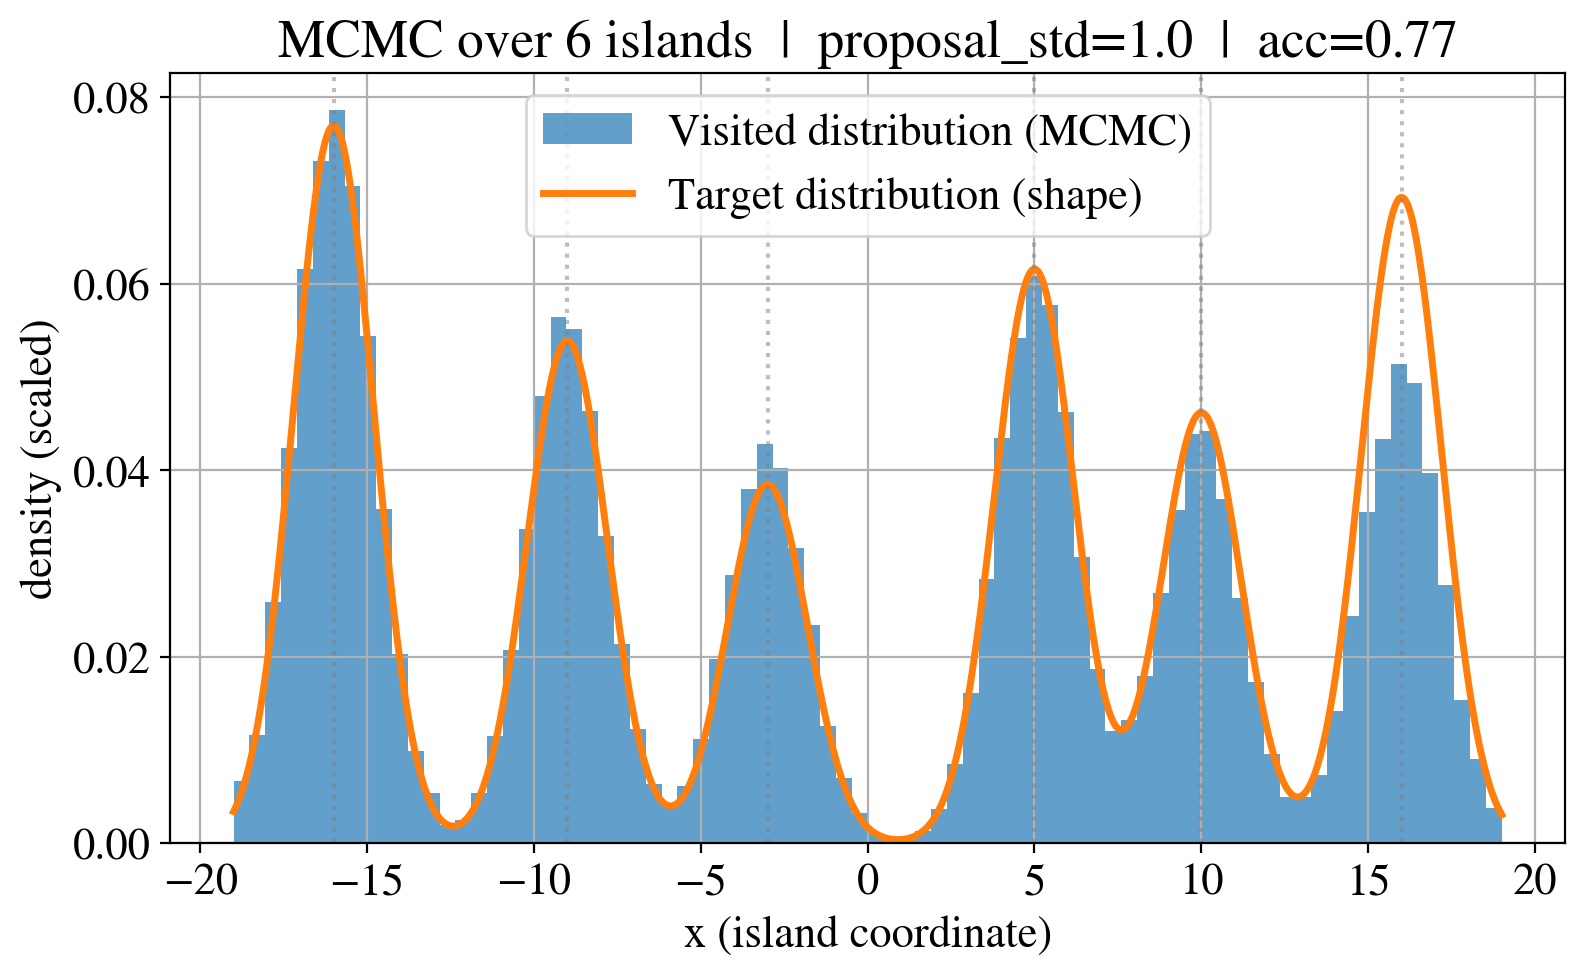

In [102]:
# -----------------------------
# 画最终分布：目标 vs 访问频率
# -----------------------------
xmin, xmax = -19, 19
xs = np.linspace(xmin, xmax, 1000)
target = pi_shape(xs)

plt.figure(figsize=(9, 5))

# MCMC 访问分布
plt.hist(samples, bins=80, range=(xmin, xmax),
         density=True, alpha=0.7, label="Visited distribution (MCMC)")

# 目标分布形状
plt.plot(xs, target/13, lw=2.5, label="Target distribution (shape)")

# 标出岛中心
for c in island_centers:
    plt.axvline(c, color="gray", linestyle=":", alpha=0.5)

plt.xlabel("x (island coordinate)")
plt.ylabel("density (scaled)")
plt.title(f"MCMC over 6 islands  |  proposal_std={proposal_std}  |  acc={acc_rate:.2f}")
plt.legend()
plt.grid(True)
plt.show()
